실행 환경 : Local (data_mine25)

**1. 프로젝트 개요**
- 목적: 주택 특성 변수 → 판매 가격(SalePrice) 예측 회귀 모델 구축
- 데이터: regression_train_public.csv (2,344건)
- 변수: 30개 독립변수 + 1개 종속변수
- Train/Test 분리: 80% / 20% (random_state=42)

---

**2. 데이터 전처리**

- **결측치 처리**
  - Garage 관련: NoGarage로 대체 (120개), Detchd 그룹 최빈값 (2개)
  - Bsmt 관련: NoBsmt로 대체 (61개), 조합별 최빈값 (2개)
  - Fireplace Qu: NoFireplace로 대체 (1,144개)
  - Lot Frontage: 회귀 예측값으로 대치 (393개, Lasso CV RMSE: 16.90)
  - Total Bsmt SF: 결측 행 삭제 (1개)

- **이상치 처리**
  - 로그 변환: 왜도>1 변수 (`lot_area`, `gr_liv_area`, `total_bsmt_sf`, `open_porch_sf`, `lot_frontage`)
  - IQR 제거: k=1.5 기준 → 2,343건 → 1,937건 (약 17% 제거)

- **인코딩 & 스케일링**
  - K-Fold Target Encoding: kitchen_qual, exter_qual, bsmt_qual, fireplace_qu, paved_drive
  - One-Hot Encoding: neighborhood, ms_zoning, garage_type 등
  - RobustScaler: 모든 수치형 변수

---

**3. 모델 비교 (5-Fold CV RMSE)**

| 모델 | 변수 수 | CV RMSE | Test RMSE |
|:-----|:-------:|--------:|----------:|
| **ElasticNet** ⭐ | 77 | 24,416 | **20,682** |
| Lasso | 71 | 24,472 | 20,970 |
| Ridge 3차 | 68 | 24,527 | 20,917 |
| Ridge 1차 | 67 | 24,672 | 21,348 |
| Ridge 2차 | 42 | 25,979 | 22,451 |

---

**4. 최종 모델: ElasticNet**

- **파라미터**: alpha=0.01, l1_ratio=0.5
- **주요 영향 변수 Top 5**
  - (+) neighborhood_stonebr: +35,487.92
  - (+) gr_liv_area: +26,519.84
  - (+) neighborhood_noridge: +24,835.81
  - (-) bldg_type_duplex: -20,920.32
  - (+) neighborhood_nridght: +20,772.33

- **성능 지표 (Train / Test)**
  - R²: 0.9041 / 0.9152
  - Adj-R²: 0.8991 / 0.8941
  - MAPE: 9.53% / 9.28%
  - **최종 점수: 0.9019 / 0.9007**

---

**5. 출력 파일**
- `model.pkl`: 최종 ElasticNet 모델
- `model_lot_frontage.pkl`: Lot Frontage 결측치 예측용 모델
- `submission_train.csv`, `submission_test.csv`: 전처리 결과 + 예측값

# 1. 데이터셋 로드
- 데이터 셋 및 라이브러리 임포트
- 필요한 컬럼만 사용하여 df_selected에 저장.

In [1]:
# =============================================================================
# 라이브러리 임포트
# =============================================================================

# 기본 라이브러리
import numpy as np
import pandas as pd
import joblib

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn - 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# scikit-learn - 모델 선택 및 평가
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# scikit-learn - 전처리
from sklearn.preprocessing import RobustScaler

# scikit-learn - 피처 선택
from sklearn.feature_selection import mutual_info_regression

# =============================================================================
# 데이터 로드 및 컬럼명 매핑
# =============================================================================

df = pd.read_csv("regression_train_public.csv")

reg_map = {
    'SalePrice': 'sale_price',
    'Overall Qual': 'overall_qual',
    'Overall Cond': 'overall_cond',
    'Neighborhood': 'neighborhood',
    'Gr Liv Area': 'gr_liv_area',
    'MS Zoning': 'ms_zoning',
    'Lot Area': 'lot_area',
    'Lot Frontage': 'lot_frontage',
    'Total Bsmt SF': 'total_bsmt_sf',
    'Year Built': 'year_built',
    'Year Remod/Add': 'year_remod_add',
    'Yr Sold': 'yr_sold',
    'Full Bath': 'full_bath',
    'Half Bath': 'half_bath',
    'Bedroom AbvGr': 'bedroom_abv_gr',
    'Kitchen Qual': 'kitchen_qual',
    'Garage Type': 'garage_type',
    'Garage Finish': 'garage_finish',
    'Garage Cars': 'garage_cars',
    'Bsmt Qual': 'bsmt_qual',
    'Bsmt Exposure': 'bsmt_exposure',
    'BsmtFin Type 1': 'bsmt_fin_type1',
    'Exter Qual': 'exter_qual',
    'Heating QC': 'heating_qc',
    'Fireplace Qu': 'fireplace_qu',
    'Central Air': 'central_air',
    'Fireplaces': 'fireplaces',
    'Paved Drive': 'paved_drive',
    'Open Porch SF': 'open_porch_sf',
    'Bldg Type': 'bldg_type',
    'Sale Condition': 'sale_condition'
}

# 1) 컬럼명 변환
df.columns = df.columns.str.strip()  # 공백 제거
df = df.rename(columns=reg_map)

# 2) 범주형 변수 값을 소문자로 통일 (테스트 데이터와 일관성 유지)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower()


# 3) 필요한 컬럼만 선택 (Target 포함 31개)

df_selected = df[list(reg_map.values())]

# 재공지_v2.md의 [규칙 2]에 따라, 학습에 사용하지 않는 나머지 50개 컬럼은 여기서 미리 제거할 수 있습니다.

# 2. 결측치 처리

### 2.1 결측치 확인
- df_selected의 결측치 비율과 개수를 출력한 결과, 결측치가 존재하는 변수는 "Lot Frontage", "Total Bsmt SF", "Garage Type", "Garage Finish", "Garage Cars", "Bsmt Qual", "Bsmt Exposure", "BsmtFin Type 1", "Fireplace Qu" 로 총 9개이다.

In [2]:
# 결측치 개수와 비율 계산
missing_count = df_selected.isnull().sum()
missing_ratio = (df_selected.isnull().sum() / len(df_selected)) * 100

# 결측치가 있는 변수만 필터링
missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_ratio(%)': missing_ratio
})

missing_df = missing_df[missing_df['missing_count'] > 0]

# 결과 출력
print("### 📌 결측치가 존재하는 변수만 출력 ###\n")
print(missing_df)



### 📌 결측치가 존재하는 변수만 출력 ###

                missing_count  missing_ratio(%)
lot_frontage              393         16.766212
total_bsmt_sf               1          0.042662
garage_type               120          5.119454
garage_finish             122          5.204778
garage_cars                 1          0.042662
bsmt_qual                  61          2.602389
bsmt_exposure              63          2.687713
bsmt_fin_type1             61          2.602389
fireplace_qu             1144         48.805461


### 2.2 결측치 처리 - Garage 관련 변수
- Garage 관련 변수 (garage_type, garage_finish, garage_cars)
- 2개: garage_type='detchd'이지만 garage_finish만 결측 → 해당 그룹 최빈값 unf로 대체
- 120개: garage_type과 garage_finish 모두 결측 + garage_cars=0 → 실제 차고 없음으로 판단 → nogarage로 대체
- garage_cars 1개: detchd+unf 그룹 최빈값 1.0으로 대체

##### 2.2.1 garage 관련 변수 결측치 확인
- garage_finish', 'garage_cars', 'garage_type' 변수의 결측치를 확인한 결과, 각 변수들의 데이터의 다수가 결측치 또는 0인 것을 확인할 수 있다. 
- 그러나, 2개의 행에서 이 일관된 패턴과 다른 값을 가지는 것을 확인하였으며 이 데이터를 다르게 처리해야 할 필요가 있다.

In [3]:
# Garage Finish가 결측치인 행을 Garage Cars, Garage Area와 함께 출력
cols = ['garage_finish', 'garage_cars', 'garage_type']
mask_finish_nan = df_selected['garage_finish'].isnull()
subset_finish_nan = df_selected.loc[mask_finish_nan, cols]
print("--- Garage Finish 결측치 행 (Garage Cars, Garage Type 포함) ---")
display(subset_finish_nan)

--- Garage Finish 결측치 행 (Garage Cars, Garage Type 포함) ---


,garage_finish,garage_cars,garage_type
4,NaN,0.0,NaN
10,NaN,0.0,NaN
95,NaN,0.0,NaN
111,NaN,0.0,NaN
114,NaN,0.0,NaN
...,...,...,...
2305,NaN,0.0,NaN
2311,NaN,0.0,NaN
2328,NaN,0.0,NaN
2332,NaN,0.0,NaN


##### 2.2.2 다른 패턴이 확인된 2개의 데이터 결측치 처리
- 2개의 행만 출력해 확인한 결과, garage_type이 'Detch' 값을 가지고 있었으며, 둘 중 하나의 데이터에서는 garege_cars가 1.0인 값을 가지고 있는 것을 확인할 수 있었다. 이를 최대한 활용하여 결측치를 처리한다면 다른 패턴을 보이는 결측치를 보다 정확히 처리할 수 있을 것으로 판단된다.
- 2개의 데이터가 동일한 패턴을 보이는 garage_type 변수를 결측치 대치의 근거로 사용하였다. 채우고자 하는 garage_finish 변수는 범주형 변수이므로 최빈값을 사용하였으며, garage_cars 변수는 garage_finish 변수의 결측치를 채운 후, garage_finish 변수와 garage_type의 변수를 활용하여 최반값으로 결측치를 처리했다.   
- 차고 유형이 "Detchd" 인 데이터 그룹에서 garage finish의 최빈값은 "Unf" 였으며, 이 값으로 결측치를 채웠다.

In [4]:
# 2개의 데이터 확인 

# 조건:
# 1) Garage Finish는 결측치
# 2) Garage Type는 결측치 아님
mask = df_selected['garage_finish'].isnull() & df_selected['garage_type'].notnull()

# 선택할 garage 관련 3개 변수
cols = ['garage_finish', 'garage_type', 'garage_cars', 'total_bsmt_sf']

# 조건에 해당하는 행 + 3개 변수만 출력
subset = df_selected.loc[mask, cols]
print(subset)



     garage_finish garage_type  garage_cars  total_bsmt_sf
525            NaN      detchd          1.0         1242.0
1225           NaN      detchd          NaN          859.0


In [5]:
# Garage Finish 결측치 처리 - 2개의 데이터

# 1) Garage Type == 'Detchd' 인 데이터 추출
detchd_group = df_selected[df_selected['garage_type'] == 'detchd']
print("### Garage Type = 'Detchd' 인 데이터 ###")
print(detchd_group[['garage_type', 'garage_finish', 'garage_cars']].head(10))

# 2) Garage Type == 'Detchd'인 그룹 안에서 Garage Finish 최빈값 구하기
mode_finish = detchd_group['garage_finish'].mode()[0]
print("최종 Garage Finish 최빈값:", mode_finish)

# 3) Garage Finish 결측치에 위의  최빈값 넣기
df_selected.loc[mask, 'garage_finish'] = mode_finish

### Garage Type = 'Detchd' 인 데이터 ###
   garage_type garage_finish  garage_cars
3       detchd           unf          2.0
14      detchd           unf          1.0
18      detchd           unf          1.0
24      detchd           unf          1.0
31      detchd           unf          2.0
32      detchd           unf          2.0
33      detchd           unf          1.0
36      detchd           unf          1.0
47      detchd           unf          1.0
55      detchd           unf          1.0
최종 Garage Finish 최빈값: unf


##### 2.2.3 2개의 데이터 중 garage_cars 결측치 처리
- 위 코드에서 garage_finish의 결측치를 채웠으니 변수를 사용할 수 있다. garage_type이 "Detchd"이고, garage_finish가 "Unf"인 그룹에서 garage_cars의 최빈값은 1.0이었다. 이 값으로 결측치를 채웠다.

In [6]:
# Garage Cars 결측치 처리

# 1) Garage Finish = 'Unf' & Garage Type = 'Detchd' 데이터 출력

mask_group = (df_selected['garage_finish'] == 'unf') & (df_selected['garage_type'] == 'detchd')

group_unf_detchd = df_selected.loc[mask_group, ['garage_finish', 'garage_type', 'garage_cars']]

print("### Garage Finish='unf' & Garage Type='detchd' 데이터 ###")
print(group_unf_detchd)


# 2) 이 그룹 내부에서 Garage Cars 최빈값 구하기

# Garage Cars 최빈값(mode)
cars_mode = group_unf_detchd['garage_cars'].mode()[0]

print("\n이 그룹 내부 Garage Cars 최빈값:", cars_mode)


# 3) Garage Cars 결측치 채우기

# 결측치 조건: Garage Cars가 비어있고, 동일 그룹 조건도 만족
mask_cars_missing = df_selected['garage_cars'].isnull() & mask_group
df_selected.loc[mask_cars_missing, 'garage_cars'] = cars_mode

### Garage Finish='unf' & Garage Type='detchd' 데이터 ###
     garage_finish garage_type  garage_cars
3              unf      detchd          2.0
14             unf      detchd          1.0
18             unf      detchd          1.0
24             unf      detchd          1.0
31             unf      detchd          2.0
...            ...         ...          ...
2327           unf      detchd          1.0
2330           unf      detchd          2.0
2333           unf      detchd          2.0
2338           unf      detchd          2.0
2342           unf      detchd          1.0

[584 rows x 3 columns]

이 그룹 내부 Garage Cars 최빈값: 1.0


##### 2.2.4 동일한 패턴이 관찰된 120개의 결측치 처리
- df_selected에서 확인할 수 있는 데이터는 garage_cars가 전부이므로, 이 데이터를 사용하여 결측치를 처리한다.
- 예상대로 실제 차고가 존재하지 않는 120개의 데이터의 garage cars 값은 전부 0이었으며, nogarage로 값을 채웠다.
- 원본 csv에는 Garage Area 변수가 있다. 이 변수를 확인한 결과, 결측치인 120개의 데이터 모두 Garage Area 값이 0으로 나타났다. 이는 차고 면적이 0임을 의미하므로, '차고 없음'의 근거가 될 수 있다

In [7]:
# Garage Type과 Garage Finish가 모두 결측치인 데이터의 Garage Area 확인 (원본 df 사용)
# → Garage Area = 0 이면 "차고가 없다"는 직접적인 근거

mask_both_missing = df['garage_type'].isnull() & df['garage_finish'].isnull()
subset = df.loc[mask_both_missing, ['garage_type', 'garage_finish', 'garage_cars', 'Garage Area']]

print("### Garage Type & Garage Finish 모두 결측치인 데이터 ###")
print(f"총 {len(subset)}개 데이터\n")

print("Garage Area 값 분포:")
print(subset['Garage Area'].value_counts(dropna=False))

### Garage Type & Garage Finish 모두 결측치인 데이터 ###
총 120개 데이터

Garage Area 값 분포:
Garage Area
0.0    120
Name: count, dtype: int64


In [8]:
# Garage Finish와 Garage Type 결측치 처리 (120개의 데이터) 

# 1) finish와 type 둘 다 결측치인 120개 행 출력

mask_both_missing = df_selected['garage_finish'].isnull() & df_selected['garage_type'].isnull()

subset_both_missing = df_selected.loc[mask_both_missing, ['garage_finish', 'garage_type', 'garage_cars']]

print("### Garage Finish & Garage Type 모두 결측치인 120개 데이터의 Garage Cars 값 ###")
print(subset_both_missing['garage_cars'].values)

# 2) cars 값이 전부 0인지 확인 -> Yes -> "실제 차고 없음"의 근거
# Finish/Type 결측치는 'NoGarage' 으로 채움

if (subset_both_missing['garage_cars'] == 0).all():
    print("\nGarage Cars 값이 모두 0 → 차고 없음 → Finish/Type을 'nogarage'으로 채움")

    df_selected.loc[mask_both_missing, 'garage_finish'] = 'nogarage'
    df_selected.loc[mask_both_missing, 'garage_type'] = 'nogarage'
else:
    print("\nGarage Cars 값 중 0이 아닌 값이 존재!")
    non_zero_cars = subset_both_missing[subset_both_missing['garage_cars'] != 0]
    print("\n### Garage Cars 값이 0이 아닌 데이터 ###")
    print(non_zero_cars)


### Garage Finish & Garage Type 모두 결측치인 120개 데이터의 Garage Cars 값 ###
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Garage Cars 값이 모두 0 → 차고 없음 → Finish/Type을 'nogarage'으로 채움


### 2.3 결측치 처리 - Bsmt
- Bsmt 관련 변수 (bsmt_qual, bsmt_exposure, bsmt_fin_type1, total_bsmt_sf)

- 61개: total_bsmt_sf=0인 경우 → 실제 지하실 없음으로 판단 → nobsmt로 대체
- 2개: 지하실은 있지만 bsmt_exposure만 결측 → (bsmt_qual, bsmt_fin_type1) 조합별 최빈값으로 대체
- total_bsmt_sf 1개: 관련 변수 모두 결측 → 행 삭제 (2,344건 → 2,343건)

##### 2.3.1 total_bsmt_sf 변수의 결측치 처리
- total_bsmt_sf 변수의 결측치는 1개로, bsmt 관련 변수가 모두 결측치인 것을 확인하였다. 따라서 이 행의 변수를 처리할 방법에 대한 근거를 찾을 수 없어 행을 삭제하였다. 

In [9]:
# Total Bsmt SF 결측치 처리

# Total Bsmt SF 결측치 여부 
bsmt_sf_is_null = df_selected['total_bsmt_sf'].isnull()

# 결측치인 행만 출력
print("### Total Bsmt SF 결측치인 행 ###")
print(df_selected.loc[bsmt_sf_is_null, ['total_bsmt_sf', 'bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1']])

# 결측치 개수 확인
print(f"\nTotal Bsmt SF 결측치 개수: {bsmt_sf_is_null.sum()}")
print(f"삭제 전 데이터 수: {len(df_selected)}")

# 결측치인 행 삭제
df_selected = df_selected.dropna(subset=['total_bsmt_sf'])
print(f"삭제 후 데이터 수: {len(df_selected)}")
print("Total Bsmt SF 결측치 행을 삭제했습니다.")

### Total Bsmt SF 결측치인 행 ###
      total_bsmt_sf bsmt_qual bsmt_exposure bsmt_fin_type1
1222            NaN       NaN           NaN            NaN

Total Bsmt SF 결측치 개수: 1
삭제 전 데이터 수: 2344
삭제 후 데이터 수: 2343
Total Bsmt SF 결측치 행을 삭제했습니다.


##### 2.3.2 bsmt_exposure 변수의 결측치 처리
- bstm_exposure 변수의 결측치를 확인할 결과, 2개의 행에서 bstm_qual과 bstm_fin_type1 변수가 있는 것을 확인하였다. 따라서 범주형인 이 두 변수를 사용하여 결측치를 처리하였다. 
- bstm_qual과 bstm_fin_type1 변수의 조합별 최빈값을 사용하여 결측치를 처리하였다.
- 그 외의 행에서는 total_bsmt_sf가 0인 것을 확인하였다. 따라서 이 행들은 실제 지하실이 존재하지 않는다고 판단하여 'nobsmt'로 결측치를 처리하였다.

In [10]:
# Bsmt Exposure 결측치 처리

# 1) 결측치 현황 확인
bsmt_cols = ['total_bsmt_sf', 'bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1']
bsmt_exposure_null_mask = df_selected['bsmt_exposure'].isnull()
print('bsmt_exposure 결측치 개수:', bsmt_exposure_null_mask.sum())
print('bsmt_exposure 결측치 행의 Bsmt 관련 컬럼:')
print(df_selected.loc[bsmt_exposure_null_mask, bsmt_cols])

# 2) 지하실이 없는 경우 (total_bsmt_sf == 0) → 'nobsmt'로 채우기
no_bsmt_mask = (df_selected['total_bsmt_sf'] == 0) & (df_selected['bsmt_exposure'].isnull())
df_selected.loc[no_bsmt_mask, 'bsmt_exposure'] = 'nobsmt'

print('\n지하실 없는 경우 nobsmt 처리 후 bsmt_exposure 결측치:', df_selected['bsmt_exposure'].isnull().sum())

# 3) 지하실이 있지만 bsmt_exposure만 결측인 경우 → (bsmt_qual, bsmt_fin_type1) 조합의 최빈값으로 채우기
bsmt_exposure_null_mask = df_selected['bsmt_exposure'].isnull()
if bsmt_exposure_null_mask.sum() > 0:
    group_mode = (df_selected[~df_selected['bsmt_exposure'].isnull()].groupby(['bsmt_qual', 'bsmt_fin_type1'])['bsmt_exposure'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]))
    
    for idx in df_selected[bsmt_exposure_null_mask].index:
        key = (df_selected.loc[idx, 'bsmt_qual'], df_selected.loc[idx, 'bsmt_fin_type1'])
        if key in group_mode.index:
            df_selected.loc[idx, 'bsmt_exposure'] = group_mode.loc[key]

print('최종 bsmt_exposure 결측치:', df_selected['bsmt_exposure'].isnull().sum())

bsmt_exposure 결측치 개수: 62
bsmt_exposure 결측치 행의 Bsmt 관련 컬럼:
      total_bsmt_sf bsmt_qual bsmt_exposure bsmt_fin_type1
2               0.0       NaN           NaN            NaN
3               0.0       NaN           NaN            NaN
14              0.0       NaN           NaN            NaN
177             0.0       NaN           NaN            NaN
220             0.0       NaN           NaN            NaN
...             ...       ...           ...            ...
2234            0.0       NaN           NaN            NaN
2235            0.0       NaN           NaN            NaN
2236          725.0        gd           NaN            unf
2278            0.0       NaN           NaN            NaN
2305            0.0       NaN           NaN            NaN

[62 rows x 4 columns]

지하실 없는 경우 nobsmt 처리 후 bsmt_exposure 결측치: 2
최종 bsmt_exposure 결측치: 0


##### 2.3.3 'bsmt_fin_type1' 변수의 결측치 처리
- 'bsmt_fin_type1'이 결측치인 행에 대하여 bsmt 관련 열들을 출력하여 확인한 결과, total_bsmt_sf가 0이며, 다른 모든 관련 변수들이 결측치인 것을 확인하였다. 따라서 이 행은 실제 지하실이 존재하지 않는다고 판단하여 'nobsmt'로 결측치를 처리하였다.

In [11]:
# bsmt_fin_type1, bsmt_qual 결측치 처리 (지하실 없는 경우 → 'nobsmt')

# 결측치 현황 확인
print('처리 전 결측치:')
print('bsmt_fin_type1:', df_selected['bsmt_fin_type1'].isnull().sum())
print('bsmt_qual:', df_selected['bsmt_qual'].isnull().sum())

# 지하실이 없는 경우 (total_bsmt_sf == 0) → 'nobsmt'로 채우기
no_bsmt_mask = df_selected['total_bsmt_sf'] == 0
df_selected.loc[no_bsmt_mask, 'bsmt_fin_type1'] = df_selected.loc[no_bsmt_mask, 'bsmt_fin_type1'].fillna('nobsmt')
df_selected.loc[no_bsmt_mask, 'bsmt_qual'] = df_selected.loc[no_bsmt_mask, 'bsmt_qual'].fillna('nobsmt')

print('\n처리 후 결측치:')
print('bsmt_fin_type1:', df_selected['bsmt_fin_type1'].isnull().sum())
print('bsmt_qual:', df_selected['bsmt_qual'].isnull().sum())

처리 전 결측치:
bsmt_fin_type1: 60
bsmt_qual: 60

처리 후 결측치:
bsmt_fin_type1: 0
bsmt_qual: 0


### 2.4 결측치 처리 - Fireplace
- Fireplace Qu (1,144개, 48.81%)
- fireplaces=0인 경우 → 실제 벽난로 없음으로 판단 → nofireplace로 대체

##### fireplace Qu 변수의 결측치 처리
- 벽난로 품질(Fireplace Qu)의 결측치가 ‘벽난로가 실제로 없는 경우’인지 ‘값이 누락된 경우’인지 구분하였다. 벽난로가 존재하지 않는 경우에는 ‘NoFireplace’로 처리하고, 값이 누락된 경우에는 적절한 대체값을 사용한다.
- fireplace Qu의 값이 결측치이면, 벽난로의 수는 0였다. 따라서 '실제 벽난로가 존재하지 않는 경우'로 판단하여, 'Nofireplace' 값으로 대체하였다.

In [12]:
# fireplace 관련 변수 자동 탐색
fireplace_cols = [col for col in df_selected.columns if "fire" in col]

print("### Fireplace 관련 변수 목록 ###")
print(fireplace_cols)

### Fireplace 관련 변수 목록 ###
['fireplace_qu', 'fireplaces']


In [13]:
# Fireplace Qu 결측치 처리

# 1) fireplaces(벽난로 수) = 0 이면 fireplace_qu 가 결측치? - Yes

mask = (df_selected['fireplaces'] == 0) & (df_selected['fireplace_qu'].isnull())

subset = df_selected.loc[mask, ['fireplaces', 'fireplace_qu']]

print("### fireplaces = 0 AND fireplace_qu is NULL 인 데이터 ###")
print(subset)
print("\n개수:", len(subset))

# 2) fireplace_qu 결측치 - 'NoFireplace'로 채움

df_selected.loc[mask, 'fireplace_qu'] = 'nofireplace'

print("\n### fireplace_qu 결측치를 'nofireplace' 으로 채운 후 확인 ###")
print(df_selected.loc[df_selected['fireplaces'] == 0, ['fireplaces', 'fireplace_qu']].head(10))

### fireplaces = 0 AND fireplace_qu is NULL 인 데이터 ###
      fireplaces fireplace_qu
1              0          NaN
2              0          NaN
3              0          NaN
4              0          NaN
10             0          NaN
...          ...          ...
2336           0          NaN
2338           0          NaN
2339           0          NaN
2341           0          NaN
2343           0          NaN

[1143 rows x 2 columns]

개수: 1143

### fireplace_qu 결측치를 'nofireplace' 으로 채운 후 확인 ###
    fireplaces fireplace_qu
1            0  nofireplace
2            0  nofireplace
3            0  nofireplace
4            0  nofireplace
10           0  nofireplace
13           0  nofireplace
15           0  nofireplace
16           0  nofireplace
18           0  nofireplace
21           0  nofireplace


### 2.5 결측치 처리 - Lot Frontage
- Lot Frontage (393개, 16.77%)
- 다른 결측치 처리 완료 후, 결측치가 없는 변수들로 회귀 모델 학습
- Ridge vs Lasso vs ElasticNet 비교:
    - Ridge CV RMSE: 17.02
    - Lasso CV RMSE: 16.90
    - ElasticNet CV RMSE: 16.97
- 예측값으로 결측치 대치
- 모델 저장: model_lot_frontage.pkl (피처 98개 사용)

##### 2.5.1 lot frontage 변수의 결측치 처리
- lot frontage의 결측치 비율은 16.7%로, 수치형 변수이다. 따라서 결측치 처리가 끝난 변수를 사용하여 lot frontage의 결측치를 예측하는 새로운 회귀 모델을 생성하고, 결측치를 모델이 예측한 lot frontage 값으로 대치한다.
- 타깃 변수를 제외하고 사용 가능한 모든 변수를 사용하였으며, 범주형 변수는 더미변수로 만들어 사용하였다. 
- 변수 선택은 Ridge와 Lasso를 사용하였으며, 하이퍼 파라미터 튜닝에는 GrideSearchCV를 사용하였다. 이 중 가장 RMSE가 낮은 모델을 사용하여 결측치를 대치하고 이 모델을 pkl로 저장하여 테스트 데이터에서 결측치를 처리해야 할 필요가 있을 때 사용할 수 있게 하였다. 

In [14]:
# =============================================================================
# lot_frontage 결측치 회귀 대치 (다른 변수 전처리 완료 후)
# =============================================================================
# Garage, Bsmt, Fireplace 등 다른 범주형 변수의 결측치 처리가 완료된 상태에서
# 회귀 모델을 학습하여 lot_frontage 결측치를 예측

# 1. lot_frontage 결측치 여부 마스크 생성
mask_lot_nan = df_selected['lot_frontage'].isnull()
mask_lot_not_nan = ~mask_lot_nan

print(f"lot_frontage 결측치 개수: {mask_lot_nan.sum()}")

# 2. 사용할 피처 정의

# (1) 수치형 피처
num_features_lot = [
    'lot_area', 'gr_liv_area', 'total_bsmt_sf', 
    'overall_qual', 'overall_cond',
    'year_built', 'year_remod_add', 'yr_sold',
    'full_bath', 'half_bath', 'bedroom_abv_gr',
    'garage_cars', 'fireplaces', 'open_porch_sf'
]

# (2) 범주형 피처 (결측치 처리 완료된 상태)
cat_features_lot = [
    'neighborhood', 'ms_zoning', 'bldg_type',
    'kitchen_qual', 'garage_type', 'garage_finish',
    'bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1',
    'exter_qual', 'heating_qc', 'fireplace_qu',
    'central_air', 'paved_drive', 'sale_condition'
]

# 실제 df_selected에 존재하는 컬럼만 사용 (안전장치)
num_features_lot = [c for c in num_features_lot if c in df_selected.columns]
cat_features_lot = [c for c in cat_features_lot if c in df_selected.columns]

# 3. 범주형 변수 더미화
df_reg = df_selected.copy()
df_reg = pd.get_dummies(df_reg, columns=cat_features_lot, drop_first=True)

# 더미 컬럼 목록
dummy_cols_lot = [
    col for col in df_reg.columns
    if any(col.startswith(f + '_') for f in cat_features_lot)
]

# 최종 피처 목록
features_for_lot_reg = num_features_lot + dummy_cols_lot

X = df_reg.loc[:, features_for_lot_reg]
y = df_selected['lot_frontage']

X_train = X.loc[mask_lot_not_nan]
y_train = y.loc[mask_lot_not_nan]
X_pred = X.loc[mask_lot_nan]

# 4. Ridge/Lasso/ElasticNet + GridSearchCV로 하이퍼파라미터 튜닝
alpha_grid = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

# KFold 설정 (shuffle=True로 데이터 섞기)
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# (1) Ridge
ridge = Ridge(random_state=42)
ridge_grid = GridSearchCV(
    ridge,
    param_grid={"alpha": alpha_grid},
    cv=kf_cv,
    scoring="neg_mean_squared_error"
)
ridge_grid.fit(X_train, y_train)

print("Ridge best alpha:", ridge_grid.best_params_["alpha"])
print("Ridge CV RMSE:", (-ridge_grid.best_score_) ** 0.5)

# (2) Lasso
lasso = Lasso(max_iter=10000, random_state=42)
lasso_grid = GridSearchCV(
    lasso,
    param_grid={"alpha": alpha_grid},
    cv=kf_cv,
    scoring="neg_mean_squared_error"
)
lasso_grid.fit(X_train, y_train)

print("Lasso best alpha:", lasso_grid.best_params_["alpha"])
print("Lasso CV RMSE:", (-lasso_grid.best_score_) ** 0.5)

# (3) ElasticNet
elastic = ElasticNet(max_iter=10000, random_state=42)
elastic_grid = GridSearchCV(
    elastic,
    param_grid={
        "alpha": alpha_grid,
        "l1_ratio": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    },
    cv=kf_cv,
    scoring="neg_mean_squared_error"
)
elastic_grid.fit(X_train, y_train)

print("ElasticNet best params:", elastic_grid.best_params_)
print("ElasticNet CV RMSE:", (-elastic_grid.best_score_) ** 0.5)

# 5. 세 모델 중 가장 좋은 모델 선택 (CV RMSE가 가장 작은 쪽)
ridge_rmse = (-ridge_grid.best_score_) ** 0.5
lasso_rmse = (-lasso_grid.best_score_) ** 0.5
elastic_rmse = (-elastic_grid.best_score_) ** 0.5

print("\n" + "="*50)
print("📊 모델별 CV RMSE 비교")
print("="*50)
print(f"  Ridge:      {ridge_rmse:.4f}")
print(f"  Lasso:      {lasso_rmse:.4f}")
print(f"  ElasticNet: {elastic_rmse:.4f}")

# 최소 RMSE 모델 선택
min_rmse = min(ridge_rmse, lasso_rmse, elastic_rmse)

if min_rmse == ridge_rmse:
    best_lot_model_name = "Ridge"
    best_lot_model = ridge_grid.best_estimator_
    best_lot_rmse = ridge_rmse
elif min_rmse == lasso_rmse:
    best_lot_model_name = "Lasso"
    best_lot_model = lasso_grid.best_estimator_
    best_lot_rmse = lasso_rmse
else:
    best_lot_model_name = "ElasticNet"
    best_lot_model = elastic_grid.best_estimator_
    best_lot_rmse = elastic_rmse

print(f"\n✅ 선택된 모델: {best_lot_model_name} (CV RMSE={best_lot_rmse:.4f})")

# 6. 최적 모델로 결측치 예측
lot_pred = best_lot_model.predict(X_pred)

# 7. 결측치에 예측값 대입
df_selected.loc[mask_lot_nan, 'lot_frontage'] = lot_pred

print("\nlot_frontage 결측치가 회귀 예측값으로 대치되었습니다.")
print("결측치 개수:", df_selected['lot_frontage'].isnull().sum())

# 대치된 값(예측값) 샘플 출력
print("\n대치된 lot_frontage 값 샘플 (상위 10개):")
print(lot_pred[:10])

# =============================================================================
# 📌 lot_frontage 결측치 대치 모델 저장
# =============================================================================
joblib.dump({
    'model': best_lot_model,
    'features': features_for_lot_reg,
    'num_features': num_features_lot,
    'cat_features': cat_features_lot
}, "model_lot_frontage.pkl")

print(f"\n" + "="*60)
print(f"📁 model_lot_frontage.pkl 저장 완료!")
print("="*60)
print(f"모델 타입: {type(best_lot_model).__name__}")
print(f"피처 개수: {len(features_for_lot_reg)}")

lot_frontage 결측치 개수: 393
Ridge best alpha: 5
Ridge CV RMSE: 17.016297862484386
Ridge best alpha: 5
Ridge CV RMSE: 17.016297862484386
Lasso best alpha: 0.05
Lasso CV RMSE: 16.902035800573646
Lasso best alpha: 0.05
Lasso CV RMSE: 16.902035800573646
ElasticNet best params: {'alpha': 0.01, 'l1_ratio': 0.9}
ElasticNet CV RMSE: 16.973558438518836

📊 모델별 CV RMSE 비교
  Ridge:      17.0163
  Lasso:      16.9020
  ElasticNet: 16.9736

✅ 선택된 모델: Lasso (CV RMSE=16.9020)

lot_frontage 결측치가 회귀 예측값으로 대치되었습니다.
결측치 개수: 0

대치된 lot_frontage 값 샘플 (상위 10개):
[93.31381973 92.29227094 34.55537946 79.15006835 74.44316274 77.04736646
 70.64983818 91.93346907 53.67090505 26.66820745]

📁 model_lot_frontage.pkl 저장 완료!
모델 타입: Lasso
피처 개수: 98
ElasticNet best params: {'alpha': 0.01, 'l1_ratio': 0.9}
ElasticNet CV RMSE: 16.973558438518836

📊 모델별 CV RMSE 비교
  Ridge:      17.0163
  Lasso:      16.9020
  ElasticNet: 16.9736

✅ 선택된 모델: Lasso (CV RMSE=16.9020)

lot_frontage 결측치가 회귀 예측값으로 대치되었습니다.
결측치 개수: 0

대치된 lot_frontage

### 2.6 결측치 검토
- 모든 결측치 처리를 완료한 후, 남아있는 결측치가 있는지 확인한다.

In [15]:
print("### 최종 결측치 개수 (0이 아닌 컬럼만) ###")
missing_final = df_selected.isnull().sum()
print(missing_final[missing_final > 0])

### 최종 결측치 개수 (0이 아닌 컬럼만) ###
Series([], dtype: int64)


# 3. 이상치 처리
- 왜도를 기준으로 로그 변환
    - lot_area, opne_porch_sf, lot_frontage, total_bsmt_sf, gr_liv_area
- IQR 기반 이상치 제거
    - lot_area, gr_liv_area, total_bsmt_sf, open_porch_sf, lot_frontage

### 3.1 로그 변환
- 왜도와 변수의 특성을 고려하여 변환 변수를 선택하였다.

##### 3.1.1 로그 변환
- 타겟 변수를 제외한 수치형 변수에 대해 각 변수의 왜도를 확인하여 로그 변환이 필요한 변수를 선정하였다. 선정된 변수 중 연도형·등급형·카운트형 변수는 로그 변환의 효과가 낮아 제외하였으며, 최종 선정된 log_cols에 대해 로그 변환을 적용하였다.
    - 점수형 변수(overall_qual, overall_cond): 원래 분포가 안정적이어서 로그 변환 시 오히려 비틀림이 생기고 해석성이 떨어진다.
    - 연도형 변수(year_built, year_remod_add, yr_sold): 시간 개념일 뿐 크기 자체에 의미가 없어 로그 변환이 부적절하다.
    - 카운트형 변수(full_bath, half_bath, bedroom_abv_gr, garage_cars, fireplaces): 값의 범위가 작아 로그를 적용해도 차이가 거의 사라져 의미가 없기 때문이다.   

In [16]:
# 이상치 처리

# 타깃변수
target_col = 'sale_price'

# 수치형 컬럼만 추출 (타깃 제외)
num_cols = df_selected.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_feature_cols = [col for col in num_cols if col != target_col]

print("수치형 변수 개수:", len(num_feature_cols))
print(num_feature_cols)

수치형 변수 개수: 15
['overall_qual', 'overall_cond', 'gr_liv_area', 'lot_area', 'lot_frontage', 'total_bsmt_sf', 'year_built', 'year_remod_add', 'yr_sold', 'full_bath', 'half_bath', 'bedroom_abv_gr', 'garage_cars', 'fireplaces', 'open_porch_sf']


In [17]:
# 각 수치형 변수 왜도 계산(왜도: 데이터 분포가 한쪽으로 치우친 정도)
skew_values = df_selected[num_feature_cols].skew().sort_values(ascending=False)
print("왜도:\n", skew_values)

# 왜도 절대값 기준으로 로그 변환 후보 선택
# 왜도가 0.8~1.3 사이인 변수는 없음 ->  왜도 기준 : 1 
skew_threshold = 1.0
skewed_cols = skew_values[skew_values.abs() > skew_threshold].index.tolist()

print("\n로그 변환 후보(왜도 기준):")
print(skewed_cols)

왜도:
 lot_area          13.742643
open_porch_sf      2.664050
lot_frontage       1.624631
total_bsmt_sf      1.343278
gr_liv_area        1.303565
fireplaces         0.771242
half_bath          0.729311
overall_cond       0.596609
bedroom_abv_gr     0.315188
overall_qual       0.204210
full_bath          0.183324
yr_sold            0.126360
garage_cars       -0.211890
year_remod_add    -0.429102
year_built        -0.595217
dtype: float64

로그 변환 후보(왜도 기준):
['lot_area', 'open_porch_sf', 'lot_frontage', 'total_bsmt_sf', 'gr_liv_area']


In [18]:
# 1) 로그 변환에서 제외할 수치형 변수들
#    - 점수형(Overall)
#    - 연도형(Year, Yr Sold)
#    - 카운트형(욕실 수, 방 수, 차고 수, 벽난로 수)

exclude_from_log = [
    'overall_qual', 'overall_cond',
    'year_built', 'year_remod_add', 'yr_sold',
    'full_bath', 'half_bath', 'bedroom_abv_gr',
    'garage_cars', 'fireplaces'
]

# 2) 실제로 로그 변환할 컬럼 (왜도 기준 후보 - 제외 목록)
log_cols = [col for col in skewed_cols if col not in exclude_from_log]

print("\n실제로 로그 변환할 컬럼:")
print(log_cols)


실제로 로그 변환할 컬럼:
['lot_area', 'open_porch_sf', 'lot_frontage', 'total_bsmt_sf', 'gr_liv_area']


In [19]:
# 3) 로그 변환 적용
df_log = df_selected.copy()

for col in log_cols:
    if col in df_log.columns:
        df_log[col] = np.log1p(df_log[col])   # log1p = log(1+x), 0 값 안전 처리
    else:
        print(f"[경고] log_cols에 있지만 df에 없는 컬럼: {col}")

print("\n로그 변환 완료!")
print("로그 변환 후 컬럼 수:", len(df_log.columns))


로그 변환 완료!
로그 변환 후 컬럼 수: 31


##### 3.1.2 로그 변환 시각화 
- 로그 변환 전후의 분포를 시각화하여 비교하였다. 로그 변환 후 분포가 안정된 것을 확인할 수 있다. 

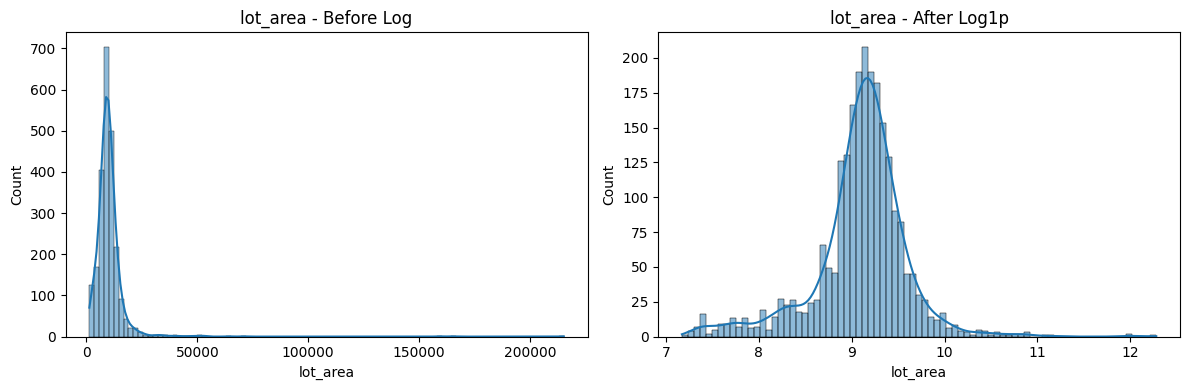

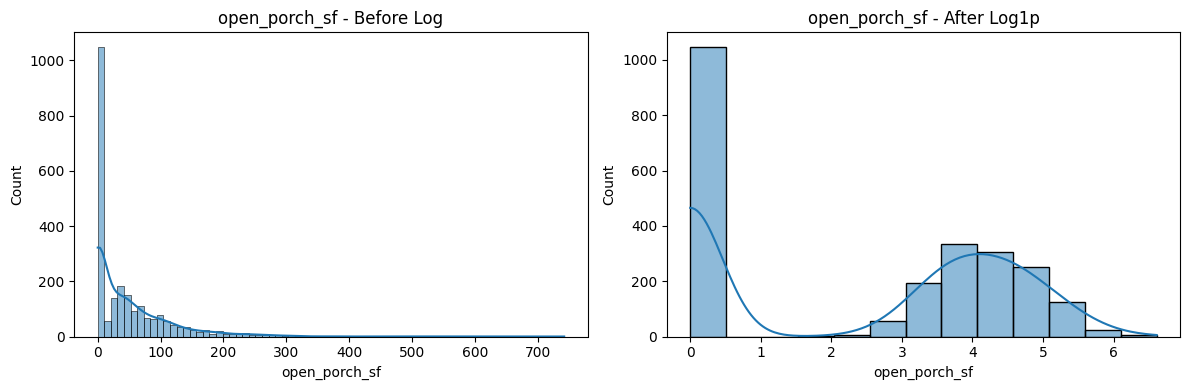

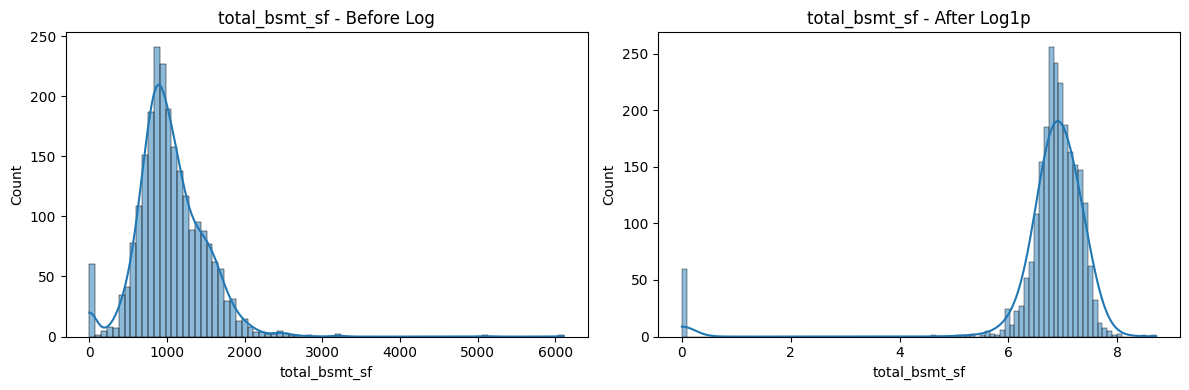

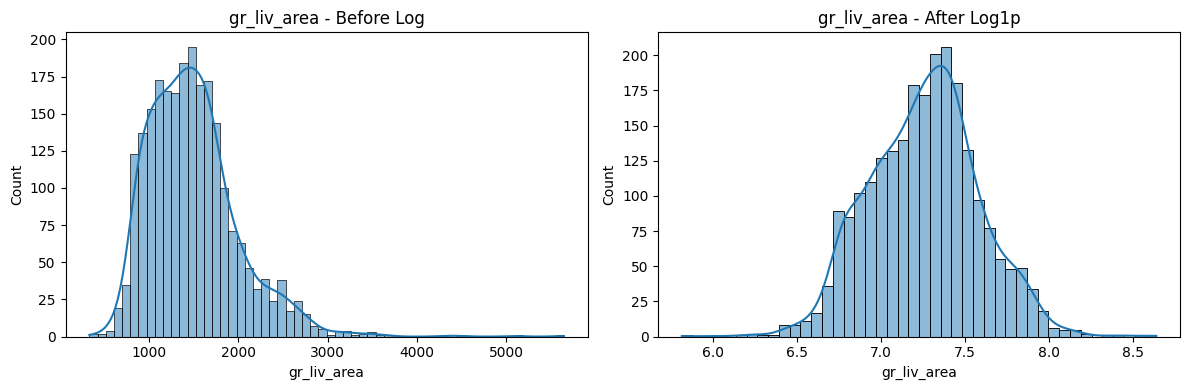

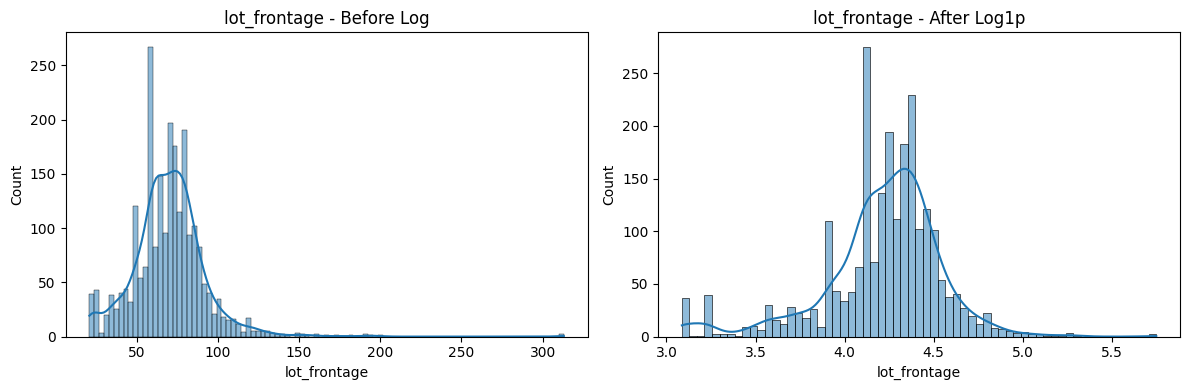

In [20]:
# 로그 변환 후 분포 변화 시각화

def plot_log_effect_hist(df_before, df_after, col):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df_before[col], kde=True)
    plt.title(f"{col} - Before Log")

    plt.subplot(1, 2, 2)
    sns.histplot(df_after[col], kde=True)
    plt.title(f"{col} - After Log1p")

    plt.tight_layout()
    plt.show()

plot_log_effect_hist(df_selected, df_log, 'lot_area')
plot_log_effect_hist(df_selected, df_log, 'open_porch_sf')
plot_log_effect_hist(df_selected, df_log, 'total_bsmt_sf')
plot_log_effect_hist(df_selected, df_log, 'gr_liv_area')
plot_log_effect_hist(df_selected, df_log, 'lot_frontage')

### 3.2 이상치 제거
- 로그 변환 후에도 이상치가 존재할 수 있는 변수들에 대해 IQR을 적용하여 이상치를 탐색한 후 제거하였다. 

##### 3.2.1 IQR 기반 이상치 제거
- 이상치 제거는 IQR 방식을 사용하였다. 각 변수별로 1사분위수(Q1), 3사분위수(Q3), IQR(=Q3-Q1)을 계산한 후, 각 변수의 값이 Q1 - k*IQR 보다 작거나 Q3 + k*IQR 보다 큰 경우를 이상치로 정의하였다.

In [21]:
# 이상치 제거

# 5) IQR로 이상치 제거할 변수들 선택 (3~4개 정도)
#    → 보통 면적/크기 관련 변수 위주로 선택
iqr_base_candidates = ['lot_area', 'gr_liv_area', 'total_bsmt_sf', 'open_porch_sf', 'lot_frontage']

# 실제로 데이터에 존재하고, log_cols에도 있는 변수만 사용
iqr_cols = [col for col in iqr_base_candidates if col in df_log.columns]

print("\nIQR 이상치 제거에 사용할 컬럼:")
print(iqr_cols)


IQR 이상치 제거에 사용할 컬럼:
['lot_area', 'gr_liv_area', 'total_bsmt_sf', 'open_porch_sf', 'lot_frontage']


In [22]:
# 6) IQR 기반 이상치 제거 함수
def remove_outliers_iqr(df_selected, cols, k=1.5):
    df_clean = df_selected.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR

        before_n = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        after_n = len(df_clean)

        print(f"[{col}] 제거 전: {before_n}, 제거 후: {after_n}, 제거된 개수: {before_n - after_n}")
    return df_clean

# 7) 실제 이상치 제거 수행
df_clean = remove_outliers_iqr(df_log, iqr_cols, k=1.5)

print("\n원본 행 개수:", len(df_selected))
print("이상치 처리 후 최종 행 개수:", len(df_clean))

[lot_area] 제거 전: 2343, 제거 후: 2126, 제거된 개수: 217
[gr_liv_area] 제거 전: 2126, 제거 후: 2113, 제거된 개수: 13
[total_bsmt_sf] 제거 전: 2113, 제거 후: 2012, 제거된 개수: 101
[open_porch_sf] 제거 전: 2012, 제거 후: 2012, 제거된 개수: 0
[lot_frontage] 제거 전: 2012, 제거 후: 1937, 제거된 개수: 75

원본 행 개수: 2343
이상치 처리 후 최종 행 개수: 1937


# 4. 범주형 변수 인코딩
- Target Encoding: kitchen_qual, bsmt_qual, exter_qual, fireplace_qu, paved_drive
- One-Hot Encoding: neighborhood, ms_zoning, garage_type, garage_finish, bsmt_exposure, bsmt_fin_type1, heating_qc, central_air, bldg_type, sale_condition

### 4.1 범주형 변수 구분
- 순서가 있는 범주형 변수는 원핫 인코딩을 적용하였고, 순서가 없는 변수는 타깃 인코딩을 사용하기 위해 변수를 분리하였다. 

In [23]:
# 1. 전체 범주형 컬럼 추출
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# 2. 순서가 있는 범주형(Ordinal) 변수 리스트 지정
ordinal_cols = [
    'kitchen_qual', 'exter_qual', 'bsmt_qual', 'fireplace_qu', 'paved_drive'
]

# 3. One-hot vs LabelEncoding 나누기
ohe_cols = [col for col in cat_cols if col not in ordinal_cols]
le_cols = [col for col in cat_cols if col in ordinal_cols]

print("One-Hot Encoding 대상:", ohe_cols)
print("Target Encoding 대상:", le_cols)

One-Hot Encoding 대상: ['neighborhood', 'ms_zoning', 'garage_type', 'garage_finish', 'bsmt_exposure', 'bsmt_fin_type1', 'heating_qc', 'central_air', 'bldg_type', 'sale_condition']
Target Encoding 대상: ['kitchen_qual', 'bsmt_qual', 'exter_qual', 'fireplace_qu', 'paved_drive']


### 4.2 타깃 인코딩
- 타겟 인코딩은 훈련 데이터의 타겟 변수의 평균값으로 각 범주형 변수를 대체하도록 하였다. 이는 순서가 있는 범주형 변수의 각 데이터 값들의 간격이 1로 동일하지 않을 수 있다는 가정을 기반으로 한다. 따라서 각 값들의 간격을 타겟 변수의 평균값으로 대체함으로써 보다 정확한 인코딩을 수행하고자 하였다. 
- 데이터 누수를 방지하기 위해, 테스트 데이터에 타겟 인코딩을 적용할 때는 훈련 데이터의 타겟 변수 평균값을 사용하였으며, 훈련 데이터에 대해서는 KFold 방식을 사용하여 각 폴드의 타겟 변수 평균값으로 인코딩을 수행하였다.

In [24]:
# 타깃 인코딩

# 1. 인덱스 리셋해서 깨끗하게 시작
df_encoded = df_clean.copy().reset_index(drop=True)

# 2. 타깃
y_target_encoding = df_encoded['sale_price']

# 3. 타겟 인코딩할 컬럼
target_encoding_cols = [
    'kitchen_qual', 'exter_qual', 'bsmt_qual', 'fireplace_qu', 'paved_drive'
]

# =============================================================================
# 📌 타깃 인코딩 매핑값 계산 및 출력 (전체 훈련 데이터 기준)
# =============================================================================
print("="*70)
print("📊 타깃 인코딩 매핑값 (전체 훈련 데이터 기준 sale_price 평균)")
print("="*70)

te_mapping_train = {}
global_mean = y_target_encoding.mean()
print(f"\n🔹 전체 평균 (Global Mean): {global_mean:,.2f}")

for col in target_encoding_cols:
    # 각 범주별 sale_price 평균 계산
    category_means = df_encoded.groupby(col)['sale_price'].mean().sort_values(ascending=False)
    te_mapping_train[col] = category_means.to_dict()
    
    print(f"\n📌 {col} 타깃 인코딩 매핑:")
    print("-" * 50)
    for category, mean_value in category_means.items():
        count = (df_encoded[col] == category).sum()
        print(f"  {category:15} → {mean_value:>12,.2f}  (n={count})")

print("\n" + "="*70)

# 4. KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. 각 컬럼에 대해 K-Fold Target Encoding
for col in target_encoding_cols:
    df_encoded[f'{col}_te'] = 0.0  # 소문자로 통일

    for fold, (train_idx, val_idx) in enumerate(kf.split(df_encoded)):
        X_train, X_val = df_encoded.iloc[train_idx], df_encoded.iloc[val_idx]
        y_train, y_val = y_target_encoding.iloc[train_idx], y_target_encoding.iloc[val_idx]

        # 범주별 평균 계산
        train_means = y_train.groupby(X_train[col]).mean()

        # 검증 세트에 매핑
        df_encoded.loc[val_idx, f'{col}_te'] = (  # 소문자로 통일
            X_val[col].map(train_means).fillna(global_mean)
        )

    df_encoded = df_encoded.drop(columns=[col])

print("\n✅ K-Fold Target Encoding 완료!")
print(f"타겟 인코딩된 컬럼: {[f'{c}_te' for c in target_encoding_cols]}")



📊 타깃 인코딩 매핑값 (전체 훈련 데이터 기준 sale_price 평균)

🔹 전체 평균 (Global Mean): 181,922.70

📌 kitchen_qual 타깃 인코딩 매핑:
--------------------------------------------------
  ex              →   328,498.90  (n=129)
  gd              →   213,202.80  (n=749)
  ta              →   143,299.37  (n=1012)
  fa              →   112,766.87  (n=47)

📌 exter_qual 타깃 인코딩 매핑:
--------------------------------------------------
  ex              →   359,128.92  (n=72)
  gd              →   234,136.15  (n=625)
  ta              →   146,071.50  (n=1218)
  fa              →   103,491.18  (n=22)

📌 bsmt_qual 타깃 인코딩 매핑:
--------------------------------------------------
  ex              →   325,984.85  (n=162)
  gd              →   206,600.20  (n=779)
  ta              →   141,019.82  (n=937)
  fa              →   110,128.63  (n=59)

📌 fireplace_qu 타깃 인코딩 매핑:
--------------------------------------------------
  ex              →   351,177.81  (n=31)
  gd              →   224,967.22  (n=492)
  ta              →   204,088.3

### 4.3 원-핫 인코딩
- 순서가 없는 범주형 변수에 대해 원-핫 인코딩을 적용하였다.

In [25]:
# 범주형은 원핫
remaining_cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_encoded, columns=remaining_cat_cols, drop_first=True)

print("One-Hot Encoding 완료!")
print(f"최종 컬럼 개수: {len(df_encoded.columns)}")
print(df_encoded.head())

One-Hot Encoding 완료!
최종 컬럼 개수: 78
   sale_price  overall_qual  overall_cond  gr_liv_area  lot_area  \
0      152000             7             5     7.223296  9.249657   
1       94550             4             6     7.439559  8.939581   
2      211000             6             5     7.630947  9.213336   
3      286000             8             5     7.589336  9.175852   
4      140000             6             5     7.226936  9.333531   

   lot_frontage  total_bsmt_sf  year_built  year_remod_add  yr_sold  ...  \
0      4.394449       6.994850        1976            1976     2009  ...   
1      4.158883       6.398595        1920            1950     2009  ...   
2      4.584967       7.049255        1988            1989     2007  ...   
3      4.442651       6.951772        1998            1998     2006  ...   
4      4.330733       7.221105        1954            1954     2006  ...   

   heating_qc_ta  central_air_y  bldg_type_2fmcon  bldg_type_duplex  \
0           True           Tr

# 5. 스케일링
- sale_price (타깃 변수)를 제외한 모든 변수에 대해 RobustScaler 적용

### 5.1 RobustScaler 적용
- 데이터가 극단값을 다수 포함하고 있다는 점에서 MinMaxScaler와 StandardScaler는 이상치에 민감하여 스케일 왜곡이 발생할 수 있다. 따라서 중앙값과 IQR 기반으로 이상치 영향을 거의 받지 않는 RobustScaler를 사용하였다.

In [26]:
# 1) 타깃 변수 이름
target_col = "sale_price"

# 2) 스케일링 할 피처 목록 (df_encoded에서 타깃만 제외)
feature_cols = [col for col in df_encoded.columns if col != target_col]

print("스케일링 대상 변수 개수:", len(feature_cols))
print("스케일링 대상 변수 목록:")
print(feature_cols)

# 3) X, y 분리
X = df_encoded[feature_cols]
y = df_encoded[target_col]

# 4) RobustScaler로 스케일링
scaler = RobustScaler()
X_scaled_array = scaler.fit_transform(X)

# 5) 다시 DataFrame으로 변환 (인덱스/컬럼 유지)
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=feature_cols,
    index=df_encoded.index
)

# 6) y와 다시 합친 최종 모델링용 데이터 (선택)
df_model = pd.concat([y, X_scaled], axis=1)

print("X_scaled shape:", X_scaled.shape)

스케일링 대상 변수 개수: 77
스케일링 대상 변수 목록:
['overall_qual', 'overall_cond', 'gr_liv_area', 'lot_area', 'lot_frontage', 'total_bsmt_sf', 'year_built', 'year_remod_add', 'yr_sold', 'full_bath', 'half_bath', 'bedroom_abv_gr', 'garage_cars', 'fireplaces', 'open_porch_sf', 'kitchen_qual_te', 'exter_qual_te', 'bsmt_qual_te', 'fireplace_qu_te', 'paved_drive_te', 'neighborhood_brkside', 'neighborhood_clearcr', 'neighborhood_collgcr', 'neighborhood_crawfor', 'neighborhood_edwards', 'neighborhood_gilbert', 'neighborhood_grnhill', 'neighborhood_idotrr', 'neighborhood_meadowv', 'neighborhood_mitchel', 'neighborhood_names', 'neighborhood_noridge', 'neighborhood_npkvill', 'neighborhood_nridght', 'neighborhood_nwames', 'neighborhood_oldtown', 'neighborhood_sawyer', 'neighborhood_sawyerw', 'neighborhood_somerst', 'neighborhood_stonebr', 'neighborhood_swisu', 'neighborhood_timber', 'neighborhood_veenker', 'ms_zoning_fv', 'ms_zoning_rh', 'ms_zoning_rl', 'ms_zoning_rm', 'garage_type_attchd', 'garage_type_basment',

In [27]:
# ==========================================
# Train / Test 분리
# ==========================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1549, 77)
X_test shape: (388, 77)
y_train shape: (1549,)
y_test shape: (388,)


# 6. 변수 선택
- Ridge: Corr& MI 기반 선택
- Lasso: 자동 변수 선택(L1 정규화)
- ElasticNet: L1과 L2 정규화의 조합을 통한 변수 선택
- 저장 파일: model.pkl

### 6.1 변수 선택 + 릿지(Ridge)
- 상관계수와 MI를 보조 지표로 활용하여 상관성이 낮고, 예측에 기여하지 않는 변수를 필터링하였다. 필터링된 변수들을 사용하여 Ridge 회귀 모델을 학습시키고, 하이퍼파라미터 튜닝을 통해 최적의 alpha 값을 선택하였다. 최종적으로 모델 성능을 평가한 후, 사용된 변수와 그 계수를 분석하였다.

- 변수 선택은 1,2,3차로 이루어 지며, 1차에서보다 2차에서, 2차에서보다 3차에서 더 적은 변수를 모델에 사용한다.

- ** MI(mutual information)는 두 변수의 확률 분포에 의존하며 두 변수 간의 관계를 측정하는 지표이다. MI는 선형적이지 않은 관계도 포착할 수 있다. 즉, 두 변수 사이에 비선형 관계가 있을 때도 유용하기에 보조 지표로 활용하여 변수를 선택한다.

##### 6.1.1 Corr&MI 계산
상관계수와 MI 값을 계산하여 변수 선택의 기준으로 삼았다. 아래의 표를 기준으로 1차, 2차, 3차의 값을 기준으로 설정하였다.
- corr 

| 매우 낮음 | 0.00 ~ 0.10 | 무시해도 됨 / 사실상 관계 없음 |

| 낮음 | 0.10 ~ 0.30 | 약한 관계 (weak) |

| 중간 | 0.30 ~ 0.50 | 중간 정도의 관계 (moderate) |

| 높음 | 0.50 ~ 0.70 | 강한 관계 (strong) |

| 매우 높음 | 0.70 이상 | 매우 강한 관계 |


- MI 값의 기준

0.00 ~ 0.01	거의 없음	y와 독립, 제거 후보

0.01 ~ 0.03	매우 약함	영향 미미

0.03 ~ 0.05	약함(weak)	어느 정도 영향 있지만 약함

0.05 ~ 0.10	중간(moderate)	유의미함

0.10 ~ 0.20	강함(strong)	중요한 변수

0.20 이상	매우 강함	상위 변수

In [28]:
# 상관계수 계산 (훈련 데이터 기준)
from sklearn.feature_selection import mutual_info_regression

corr_values = X_train.apply(lambda col: np.corrcoef(col, y_train)[0, 1])

corr_df = pd.DataFrame({
    'Variable': corr_values.index,
    'Correlation_with_y': corr_values.values
}).sort_values(by='Correlation_with_y', ascending=False)

corr_df

c:\Users\user\Documents\Projects_src\data_mine25\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\Documents\Projects_src\data_mine25\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Variable,Correlation_with_y
0,overall_qual,0.822107
17,bsmt_qual_te,0.736487
16,exter_qual_te,0.733986
15,kitchen_qual_te,0.696150
2,gr_liv_area,0.682065
...,...,...
58,bsmt_exposure_no,-0.300880
67,heating_qc_ta,-0.329513
51,garage_type_detchd,-0.386797
55,garage_finish_unf,-0.442514


In [29]:
# 절대값 상관계수 기준 정렬 (0에 가까운 순)
corr_df['abs_corr'] = corr_df['Correlation_with_y'].abs()

# 상관계수가 거의 없는 변수 n개 출력
lowest_corr_vars = corr_df.sort_values(by='abs_corr', ascending=True).head(15)

print("상관계수가 거의 없는 5개 변수:")
print(lowest_corr_vars[['Variable', 'Correlation_with_y']])


상관계수가 거의 없는 5개 변수:
                  Variable  Correlation_with_y
37    neighborhood_sawyerw            0.003545
34     neighborhood_nwames            0.005324
73   sale_condition_alloca           -0.016265
23    neighborhood_crawfor            0.020466
48     garage_type_basment           -0.023958
66           heating_qc_po           -0.025758
28    neighborhood_meadowv           -0.026024
32    neighborhood_npkvill           -0.026222
25    neighborhood_gilbert            0.031281
57        bsmt_exposure_mn           -0.033471
21    neighborhood_clearcr            0.041382
72  sale_condition_adjland           -0.047803
29    neighborhood_mitchel           -0.050050
8                  yr_sold           -0.050733
50     garage_type_carport           -0.056567


In [30]:
# MI 계산 (훈련 데이터 기준)
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    'Variable': X_train.columns,
    'MI_with_y': mi_scores
}).sort_values(by='MI_with_y', ascending=False)

mi_df

,Variable,MI_with_y
0,overall_qual,0.579082
2,gr_liv_area,0.459743
6,year_built,0.417364
12,garage_cars,0.393641
17,bsmt_qual_te,0.375745
...,...,...
28,neighborhood_meadowv,0.000000
57,bsmt_exposure_mn,0.000000
50,garage_type_carport,0.000000
48,garage_type_basment,0.000000


In [31]:
# 오름차순 정렬 → 0에 가장 가까운 변수 순서
lowest_mi_vars = mi_df.sort_values(by='MI_with_y', ascending=True).head(10)

print("MI가 거의 0인 n개 변수:")
print(lowest_mi_vars[['Variable', 'MI_with_y']])

MI가 거의 0인 n개 변수:
                 Variable  MI_with_y
28   neighborhood_meadowv   0.000000
57       bsmt_exposure_mn   0.000000
50    garage_type_carport   0.000000
48    garage_type_basment   0.000000
61     bsmt_fin_type1_lwq   0.000000
44           ms_zoning_rh   0.000000
26   neighborhood_grnhill   0.000000
21   neighborhood_clearcr   0.000000
66          heating_qc_po   0.000015
74  sale_condition_family   0.002606


##### 6.1.2 상관계수와 MI 기준 1차 Ridge 변수 선택
- |corr| < 0.05 AND MI < 0.02  (강도: 완전히 무의미한 변수 제거)

In [32]:
# 변수 선택 (1차)

# --- 1) corr_df와 mi_df 병합 ---
corr_mi_df = corr_df.merge(
    mi_df[['Variable', 'MI_with_y']],
    on='Variable',
    how='left'
).copy()

# 상관계수 절대값 계산
corr_mi_df['abs_corr'] = corr_mi_df['Correlation_with_y'].abs()


# --- 1차 필터링 기준   ---
# |corr| < 0.05 AND MI < 0.02  (강도: 완전히 무의미한 변수 제거)
first_filter_removed = corr_mi_df[
    (corr_mi_df['abs_corr'] < 0.05) & (corr_mi_df['MI_with_y'] < 0.02)
]

first_filter_kept = corr_mi_df.drop(first_filter_removed.index)

print("===== 1차 필터링: 제거된 변수들 =====")
print(first_filter_removed[['Variable', 'Correlation_with_y', 'MI_with_y']])

print("\n===== 1차 필터링: 유지된 변수 개수 =====")
print(len(first_filter_kept))


===== 1차 필터링: 제거된 변수들 =====
                  Variable  Correlation_with_y  MI_with_y
35    neighborhood_clearcr            0.041382   0.000000
37    neighborhood_crawfor            0.020466   0.008292
39    neighborhood_sawyerw            0.003545   0.013764
40   sale_condition_alloca           -0.016265   0.012435
41     garage_type_basment           -0.023958   0.000000
42           heating_qc_po           -0.025758   0.000015
43    neighborhood_meadowv           -0.026024   0.000000
44    neighborhood_npkvill           -0.026222   0.009123
45        bsmt_exposure_mn           -0.033471   0.000000
46  sale_condition_adjland           -0.047803   0.010316

===== 1차 필터링: 유지된 변수 개수 =====
67


In [33]:
# ------------------------------
# 1) 1차 필터링된 변수 이름 리스트 생성
# ------------------------------
ridge_features_1 = first_filter_kept["Variable"].tolist()

# 선택된 변수들만 훈련/테스트 데이터에서 선택
X1_train = X_train[ridge_features_1]
X1_test = X_test[ridge_features_1]

print("1차 Ridge용 X_train shape:", X1_train.shape)
print("1차 Ridge용 X_test shape:", X1_test.shape)

# ------------------------------
# 2) Ridge 모델 + 하이퍼파라미터
# ------------------------------
ridge = Ridge()

# KFold 설정 (shuffle=True로 데이터 섞기)
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_1 = GridSearchCV(
    estimator=ridge,
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=kf_cv,
    n_jobs=-1
)

# ------------------------------
# 3) 교차검증 수행 (훈련 데이터)
# ------------------------------
grid_1.fit(X1_train, y_train)

print("\n[1차 필터링] 최적 α:", grid_1.best_params_)
print("[1차 필터링] 교차검증 RMSE:", -grid_1.best_score_)

# ------------------------------
# 4) 최적 alpha로 훈련 데이터 학습
# ------------------------------
best_ridge_1 = Ridge(alpha=grid_1.best_params_['alpha'])
best_ridge_1.fit(X1_train, y_train)

# Train RMSE
y1_train_pred = best_ridge_1.predict(X1_train)
train_rmse1 = np.sqrt(mean_squared_error(y_train, y1_train_pred))
print(f"[1차 필터링] Train RMSE: {train_rmse1:.2f}")

# Test RMSE
y1_test_pred = best_ridge_1.predict(X1_test)
test_rmse1 = np.sqrt(mean_squared_error(y_test, y1_test_pred))
print(f"[1차 필터링] Test RMSE: {test_rmse1:.2f}")

# ------------------------------
# 5) 계수 정리
# ------------------------------
coef_df_1 = pd.DataFrame({
    "feature": ridge_features_1,
    "coef": best_ridge_1.coef_
}).sort_values(by="coef", key=abs, ascending=False)

print("\n[1차 필터링] Ridge 계수 Top20")
print(coef_df_1.head(20))

# ------------------------------
# 6) Ridge가 실제로 사용한 변수 개수
# ------------------------------
print(f"\n[1차 필터링] Ridge 사용 변수 개수: {len(coef_df_1)}")

1차 Ridge용 X_train shape: (1549, 67)
1차 Ridge용 X_test shape: (388, 67)

[1차 필터링] 최적 α: {'alpha': 5}
[1차 필터링] 교차검증 RMSE: 24671.979554989586
[1차 필터링] Train RMSE: 23365.52
[1차 필터링] Test RMSE: 21348.17

[1차 필터링] Ridge 계수 Top20
                   feature          coef
21    neighborhood_stonebr  39088.952016
22    neighborhood_noridge  29810.769860
4              gr_liv_area  26979.608876
12    neighborhood_nridght  26127.092421
43        bldg_type_duplex -19633.648360
18        bsmt_exposure_gd  19468.669604
16  sale_condition_partial  18702.718915
0             overall_qual  18520.449183
32        bldg_type_twnhse -18310.488288
7            total_bsmt_sf  13852.775316
47      bsmt_fin_type1_unf -11952.300039
35    neighborhood_gilbert -11003.706748
36     neighborhood_nwames -10504.689927
3          kitchen_qual_te   9986.884985
1             bsmt_qual_te   9184.694566
60    neighborhood_oldtown  -9139.995804
2            exter_qual_te   9139.555220
29            ms_zoning_fv   8680.141194

##### 6.1.3 상관계수와 MI 기준 Ridge 변수 선택 2차
- |corr| < 0.10 OR MI < 0.03  (강도: 약한 변수 제거)


In [34]:
# --- 2차 필터링 기준 ---
# 기준: |corr| < 0.10 OR MI < 0.03  (강도: 약한 변수 제거)
second_filter_removed = first_filter_kept[
    (first_filter_kept['abs_corr'] < 0.10) | (first_filter_kept['MI_with_y'] < 0.03)
]

second_filter_kept = first_filter_kept.drop(second_filter_removed.index)

print("\n===== 2차 필터링: 제거된 변수들 =====")
print(second_filter_removed[['Variable', 'Correlation_with_y', 'MI_with_y']])

print("\n===== 2차 필터링: 최종 유지 변수 개수 =====")
print(len(second_filter_kept))



===== 2차 필터링: 제거된 변수들 =====
                 Variable  Correlation_with_y  MI_with_y
21   neighborhood_stonebr            0.278690   0.022993
24    garage_type_builtin            0.264676   0.027386
30    neighborhood_timber            0.110240   0.013917
31   neighborhood_collgcr            0.105626   0.019324
32       bldg_type_twnhse            0.103387   0.013704
33         bedroom_abv_gr            0.094263   0.070269
34   neighborhood_veenker            0.090528   0.003671
36   neighborhood_gilbert            0.031281   0.063158
38    neighborhood_nwames            0.005324   0.020234
47   neighborhood_mitchel           -0.050050   0.017990
48                yr_sold           -0.050733   0.023904
49    garage_type_carport           -0.056567   0.000000
50  sale_condition_family           -0.061484   0.002606
51           ms_zoning_rh           -0.071943   0.000000
52     neighborhood_swisu           -0.073378   0.007238
53       bldg_type_duplex           -0.078587   0.020504
54

In [35]:
# 1) 2차 필터링된 변수 리스트
ridge_features_2 = second_filter_kept["Variable"].tolist()
ridge_features_2 = [col for col in ridge_features_2 if col in X_train.columns]

# 선택된 변수들만 훈련/테스트 데이터에서 선택
X2_train = X_train[ridge_features_2]
X2_test = X_test[ridge_features_2]

print("\n2차 Ridge용 X_train shape:", X2_train.shape)
print("2차 Ridge용 X_test shape:", X2_test.shape)
print("사용된 변수 개수:", len(ridge_features_2))


# 2) Ridge + GridSearchCV
ridge2 = Ridge()

grid_2 = GridSearchCV(
    estimator=ridge2,
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=kf_cv,
    n_jobs=-1
)

# 3) 교차검증 수행 (훈련 데이터)
grid_2.fit(X2_train, y_train)

print("\n[2차 필터링] 최적 alpha:", grid_2.best_params_["alpha"])
print("[2차 필터링] 교차검증 RMSE:", -grid_2.best_score_)


# 4) 최적 alpha로 훈련 데이터 학습
best_ridge_2 = Ridge(alpha=grid_2.best_params_['alpha'])
best_ridge_2.fit(X2_train, y_train)

# Train RMSE
y2_train_pred = best_ridge_2.predict(X2_train)
train_rmse2 = np.sqrt(mean_squared_error(y_train, y2_train_pred))
print(f"[2차 필터링] Train RMSE: {train_rmse2:.2f}")

# Test RMSE
y2_test_pred = best_ridge_2.predict(X2_test)
test_rmse2 = np.sqrt(mean_squared_error(y_test, y2_test_pred))
print(f"[2차 필터링] Test RMSE: {test_rmse2:.2f}")


# 5) 계수 정리
coef_df_2 = pd.DataFrame({
    "feature": ridge_features_2,
    "coef": best_ridge_2.coef_
})

# 절댓값 큰 순서로 정렬
coef_df_2 = coef_df_2.reindex(coef_df_2["coef"].abs().sort_values(ascending=False).index)

print("\n[2차 필터링] Ridge 계수 Top20")
print(coef_df_2.head(20))

print(f"\n[2차 필터링] Ridge 사용 변수 개수: {len(coef_df_2)}")


2차 Ridge용 X_train shape: (1549, 41)
2차 Ridge용 X_test shape: (388, 41)
사용된 변수 개수: 41

[2차 필터링] 최적 alpha: 5
[2차 필터링] 교차검증 RMSE: 25978.589713441477
[2차 필터링] Train RMSE: 25129.12
[2차 필터링] Test RMSE: 22451.37

[2차 필터링] Ridge 계수 Top20
                   feature          coef
21    neighborhood_noridge  33322.556605
4              gr_liv_area  24735.810209
16  sale_condition_partial  22450.763986
18        bsmt_exposure_gd  22440.281637
12    neighborhood_nridght  22008.230189
0             overall_qual  19886.225758
7            total_bsmt_sf  13595.636619
11      bsmt_fin_type1_glq  12261.630506
3          kitchen_qual_te  12085.375526
2            exter_qual_te  10532.368486
35    neighborhood_oldtown -10026.327750
1             bsmt_qual_te   9863.559265
25    neighborhood_somerst   8839.857288
5              garage_cars   7720.403753
28   sale_condition_normal   7652.618703
27            ms_zoning_fv   6598.224639
10         fireplace_qu_te   6539.480014
15                lot_area   617

##### 6.1.4 상관계수와 MI 기준 Ridge 변수 선택 3차
- corr > 0.05 OR MI > 0.01 (1차보다 훨씬 많은 변수 포함)

In [36]:
# ==========================================
# 3차 필터링: corr > 0.05 OR MI > 0.01
# (1차보다 훨씬 많은 변수 포함)
# ==========================================

third_filter_kept = corr_mi_df[
    (corr_mi_df["Correlation_with_y"].abs() >= 0.05) |
    (corr_mi_df["MI_with_y"] >= 0.01)
].copy()

third_filter_kept = third_filter_kept.sort_values(by="Correlation_with_y", key=lambda x: x.abs(), ascending=False)

print("===== 3차 필터링 변수 개수 =====")
print(len(third_filter_kept))
third_filter_kept.head()


===== 3차 필터링 변수 개수 =====
69


,Variable,Correlation_with_y,abs_corr,MI_with_y
0,overall_qual,0.822107,0.822107,0.579082
1,bsmt_qual_te,0.736487,0.736487,0.375745
2,exter_qual_te,0.733986,0.733986,0.355782
3,kitchen_qual_te,0.696150,0.696150,0.329184
4,gr_liv_area,0.682065,0.682065,0.459743


In [37]:
# 3차 필터링된 변수 이름 리스트
# ==========================================
ridge_features_3 = third_filter_kept["Variable"].tolist()

# 선택된 변수들만 훈련/테스트 데이터에서 선택
X3_train = X_train[ridge_features_3]
X3_test = X_test[ridge_features_3]

print("\n3차 Ridge용 X_train shape:", X3_train.shape)
print("3차 Ridge용 X_test shape:", X3_test.shape)

# ==========================================
# Ridge + GridSearchCV
# ==========================================
ridge_3 = Ridge()
grid_3 = GridSearchCV(
    estimator=ridge_3,
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=kf_cv,
    n_jobs=-1
)

# 교차검증 수행 (훈련 데이터)
grid_3.fit(X3_train, y_train)

print("\n[3차 필터링] 최적 α:", grid_3.best_params_)
print("[3차 필터링] 교차검증 RMSE:", -grid_3.best_score_)

# ==========================================
# 최적 alpha로 훈련 데이터 학습
# ==========================================
best_ridge_3 = Ridge(alpha=grid_3.best_params_['alpha'])
best_ridge_3.fit(X3_train, y_train)

# Train RMSE
y3_train_pred = best_ridge_3.predict(X3_train)
train_rmse3 = np.sqrt(mean_squared_error(y_train, y3_train_pred))
print(f"[3차 필터링] Train RMSE: {train_rmse3:.2f}")

# Test RMSE
y3_test_pred = best_ridge_3.predict(X3_test)
test_rmse3 = np.sqrt(mean_squared_error(y_test, y3_test_pred))
print(f"[3차 필터링] Test RMSE: {test_rmse3:.2f}")

# ==========================================
# Ridge 계수 정리
# ==========================================
coef_df_3 = pd.DataFrame({
    "feature": ridge_features_3,
    "coef": best_ridge_3.coef_
}).sort_values(by="coef", key=lambda x: x.abs(), ascending=False)

print("\n[3차 필터링] Ridge 계수 Top20")
print(coef_df_3.head(20))

# ==========================================
# Ridge가 실제로 사용한 변수 개수
# ==========================================
nonzero_count_3 = sum(coef_df_3["coef"] != 0)
total_vars_3 = len(coef_df_3)

print(f"\n[3차 필터링] Ridge 사용 변수 개수: {nonzero_count_3} / {total_vars_3}")


3차 Ridge용 X_train shape: (1549, 69)
3차 Ridge용 X_test shape: (388, 69)

[3차 필터링] 최적 α: {'alpha': 5}
[3차 필터링] 교차검증 RMSE: 24527.241884533894
[3차 필터링] Train RMSE: 23120.04
[3차 필터링] Test RMSE: 20917.05

[3차 필터링] Ridge 계수 Top20
                   feature          coef
25    neighborhood_stonebr  33608.068967
4              gr_liv_area  26582.631871
26    neighborhood_noridge  23574.401102
57        bldg_type_duplex -20487.104024
12    neighborhood_nridght  19350.068348
20        bsmt_exposure_gd  19257.867696
18  sale_condition_partial  18672.630636
0             overall_qual  18460.328404
65    neighborhood_gilbert -18124.898779
53        bldg_type_twnhse -18096.214306
68    neighborhood_sawyerw -17440.591540
67     neighborhood_nwames -15479.590036
51     neighborhood_timber -14398.297930
7            total_bsmt_sf  13517.475563
52    neighborhood_collgcr -12738.943262
48      bsmt_fin_type1_unf -11739.421222
66   sale_condition_alloca  11270.694548
63    neighborhood_mitchel -10699.80994

### 6.2 Lasso
- GridSearchCV를 사용하여 alpha 값을 최적화한 후, Lasso 모델을 학습시켰다.

In [38]:
print("Lasso용 X_train shape:", X_train.shape)
print("Lasso용 X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# =====================================
# Lasso 모델 + 하이퍼파라미터 그리드 정의
# =====================================
lasso = Lasso(max_iter=10000, random_state=42)  # max_iter 늘려서 수렴 문제 방지

grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",  # RMSE 기준
    cv=kf_cv,
    n_jobs=-1
)

# =====================================
# 교차검증으로 최적 alpha 찾기 (훈련 데이터)
# =====================================
grid_lasso.fit(X_train, y_train)

print("\n[LASSO] 최적 하이퍼파라미터:", grid_lasso.best_params_)
print("[LASSO] 교차검증 최고 점수(RMSE):", -grid_lasso.best_score_)

# =====================================
# 최적 alpha로 훈련 데이터 학습
# =====================================
best_lasso = Lasso(
    alpha=grid_lasso.best_params_['alpha'],
    max_iter=10000,
    random_state=42
)
best_lasso.fit(X_train, y_train)

# Train RMSE
y_pred_train_lasso = best_lasso.predict(X_train)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
print(f"[LASSO] Train RMSE: {train_rmse_lasso:.2f}")

# Test RMSE
y_pred_test_lasso = best_lasso.predict(X_test)
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
print(f"[LASSO] Test RMSE: {test_rmse_lasso:.2f}")

# =====================================
# Lasso 변수 선택 결과(계수=0/≠0)
# =====================================
coef_series = pd.Series(best_lasso.coef_, index=X_train.columns)

# 0이 아닌 계수만 (선택된 변수들)
selected_features = coef_series[coef_series != 0].sort_values(key=lambda x: x.abs(), ascending=False)

print("\n===== LASSO가 선택한 변수들 (계수 ≠ 0, 절댓값 기준 정렬) =====")
print(selected_features)

print("\n선택된 변수 개수:", len(selected_features))
print("전체 변수 개수:", X_train.shape[1])

# 필요하면 DataFrame 형태로 보고 싶으면
coef_df = selected_features.reset_index()
coef_df.columns = ["feature", "coef"]

Lasso용 X_train shape: (1549, 77)
Lasso용 X_test shape: (388, 77)
y_train shape: (1549,)
y_test shape: (388,)

[LASSO] 최적 하이퍼파라미터: {'alpha': 100}
[LASSO] 교차검증 최고 점수(RMSE): 24472.02448720644
[LASSO] Train RMSE: 23220.93
[LASSO] Test RMSE: 20970.32

===== LASSO가 선택한 변수들 (계수 ≠ 0, 절댓값 기준 정렬) =====
neighborhood_stonebr      4.415251e+04
neighborhood_noridge      3.186133e+04
neighborhood_nridght      2.791940e+04
gr_liv_area               2.669117e+04
overall_qual              1.809015e+04
bsmt_exposure_gd          1.774445e+04
bldg_type_duplex         -1.772783e+04
bldg_type_twnhse         -1.591743e+04
sale_condition_partial    1.544150e+04
neighborhood_crawfor      1.390033e+04
total_bsmt_sf             1.329171e+04
kitchen_qual_te           1.036160e+04
exter_qual_te             9.860138e+03
bsmt_fin_type1_unf       -9.686176e+03
neighborhood_somerst      9.584404e+03
bsmt_qual_te              9.320989e+03
neighborhood_gilbert     -8.001388e+03
garage_cars               7.719205e+03
neigh

### 6.3 ElasticNet
- GridSearchCV를 사용하여 alpha 값과 l1_ratio 값을 최적화한 후, ElasticNet 모델을 학습시켰다.

In [39]:
print("ElasticNet용 X_train shape:", X_train.shape)
print("ElasticNet용 X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# ElasticNet 모델 정의
enet = ElasticNet(max_iter=10000, random_state=42)

# 하이퍼파라미터 탐색 그리드
param_grid_elastic = {
    "alpha":    [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    "l1_ratio": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
}

# GridSearchCV로 교차검증 + 튜닝 실행 (훈련 데이터)
grid_elastic = GridSearchCV(
    estimator=enet,
    param_grid=param_grid_elastic,
    cv=kf_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_elastic.fit(X_train, y_train)

print("최적 하이퍼파라미터:", grid_elastic.best_params_)
print("교차검증 최고 점수(RMSE):", -grid_elastic.best_score_)

# 최적 파라미터로 훈련 데이터 학습
best_elastic = ElasticNet(
    alpha=grid_elastic.best_params_['alpha'],
    l1_ratio=grid_elastic.best_params_['l1_ratio'],
    max_iter=10000,
    random_state=42
)
best_elastic.fit(X_train, y_train)

# Train RMSE
y_pred_train_elastic = best_elastic.predict(X_train)
train_rmse_elastic = np.sqrt(mean_squared_error(y_train, y_pred_train_elastic))
print(f"ElasticNet Train RMSE: {train_rmse_elastic:.2f}")

# Test RMSE
y_pred_test_elastic = best_elastic.predict(X_test)
test_rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_test_elastic))
print(f"ElasticNet Test RMSE: {test_rmse_elastic:.2f}")

# ElasticNet이 선택한 변수 확인
coefs_elastic = best_elastic.coef_
feature_names_elastic = X_train.columns

selected_features_elastic = feature_names_elastic[coefs_elastic != 0]
removed_features_elastic  = feature_names_elastic[coefs_elastic == 0]

print("\n===== ElasticNet이 최종적으로 선택한 변수들 =====")
print(list(selected_features_elastic))
print("선택된 변수 개수:", len(selected_features_elastic))
print("전체 변수 개수:", len(feature_names_elastic))

print("\n===== ElasticNet이 제거한 변수들 =====")
print(list(removed_features_elastic))

ElasticNet용 X_train shape: (1549, 77)
ElasticNet용 X_test shape: (388, 77)
y_train shape: (1549,)
y_test shape: (388,)
최적 하이퍼파라미터: {'alpha': 0.01, 'l1_ratio': 0.5}
교차검증 최고 점수(RMSE): 24415.61194134134
ElasticNet Train RMSE: 23024.09
ElasticNet Test RMSE: 20681.72

===== ElasticNet이 최종적으로 선택한 변수들 =====
['overall_qual', 'overall_cond', 'gr_liv_area', 'lot_area', 'lot_frontage', 'total_bsmt_sf', 'year_built', 'year_remod_add', 'yr_sold', 'full_bath', 'half_bath', 'bedroom_abv_gr', 'garage_cars', 'fireplaces', 'open_porch_sf', 'kitchen_qual_te', 'exter_qual_te', 'bsmt_qual_te', 'fireplace_qu_te', 'paved_drive_te', 'neighborhood_brkside', 'neighborhood_clearcr', 'neighborhood_collgcr', 'neighborhood_crawfor', 'neighborhood_edwards', 'neighborhood_gilbert', 'neighborhood_idotrr', 'neighborhood_meadowv', 'neighborhood_mitchel', 'neighborhood_names', 'neighborhood_noridge', 'neighborhood_npkvill', 'neighborhood_nridght', 'neighborhood_nwames', 'neighborhood_oldtown', 'neighborhood_sawyer', 'neig

# 7. 모델 선택
- 최종 선택 모델: ElasticNet (Test RMSE: 20,681.72, 사용변수: 77개, alpha: 0.01, l1_ratio: 0.5)

### 7.1 모델 비교
- 이전에 수행한 Ridge, Lasso, ElasticNet 모델의 결과를 재출력하여 비교하였다. 각 모델의 CV RMSE 값을 비교하여 가장 낮은 값을 가진 모델을 최종 모델로 선택하였다.

In [40]:
# ------------------------------------------
# Adjusted R² 계산 함수
# ------------------------------------------
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


# ------------------------------------------
# 모델 평가 함수 (Train/Test 분리 버전)
# ------------------------------------------
def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name):
    """Train/Test 데이터로 학습한 모델 평가"""
    
    # Train 예측
    y_train_pred = model.predict(X_train_data)
    # Test 예측
    y_test_pred = model.predict(X_test_data)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train_data, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_data, y_test_pred))

    # R², Adjusted R² (Test 기준)
    r2 = r2_score(y_test_data, y_test_pred)
    adj_r2 = adjusted_r2(r2, n=len(y_test_data), p=X_test_data.shape[1])

    # 계수
    coefs = model.coef_
    nonzero = np.sum(coefs != 0)     # 0이 아닌 계수 개수
    total = len(coefs)

    # 계수 Top10 (절댓값 기준)
    coef_df = pd.DataFrame({
        "feature": X_train_data.columns,
        "coef": coefs
    }).sort_values(by="coef", key=lambda x: x.abs(), ascending=False)

    top10 = coef_df.head(10)

    return {
        "model": model_name,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "R²": r2,
        "Adjusted_R²": adj_r2,
        "Total_features": total,
        "Nonzero_features": nonzero,
        "Top10_coef": top10,
        "Selected_features": coef_df[coef_df["coef"] != 0]["feature"].tolist()
    }


# ----------------------------------------------------
# 📌 Ridge 1/2/3차, ElasticNet, Lasso 비교
# (Train/Test 분리된 모델들)
# ----------------------------------------------------

results = []

results.append(evaluate_model(best_ridge_1, X1_train, X1_test, y_train, y_test, "Ridge_1차"))
results.append(evaluate_model(best_ridge_2, X2_train, X2_test, y_train, y_test, "Ridge_2차"))
results.append(evaluate_model(best_ridge_3, X3_train, X3_test, y_train, y_test, "Ridge_3차"))
results.append(evaluate_model(best_elastic, X_train, X_test, y_train, y_test, "ElasticNet"))
results.append(evaluate_model(best_lasso, X_train, X_test, y_train, y_test, "Lasso"))

# ----------------------------------------------------
# 결과를 DataFrame화
# ----------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Model": r["model"],
        "Train_RMSE": r["Train_RMSE"],
        "Test_RMSE": r["Test_RMSE"],
        "Adjusted_R²": r["Adjusted_R²"],
        "Total Vars": r["Total_features"],
        "Selected Vars(≠0)": r["Nonzero_features"]
    }
    for r in results
])

print("\n===================== 모델 성능 비교 (Train/Test 분리) =====================")
print(summary_df)

# ----------------------------------------------
# 선택된 변수 목록과 Top10 계수도 필요하면 별도로 출력
# ----------------------------------------------

for r in results:
    print(f"\n====== {r['model']} : 선택된 변수(계수 ≠ 0) ======")
    print(r["Selected_features"])
    print(f"\n====== {r['model']} : 계수 절대값 Top 10 ======")
    print(r["Top10_coef"])


===================== 모델 성능 비교 (Train/Test 분리) =====================
        Model    Train_RMSE     Test_RMSE  Adjusted_R²  Total Vars  \
0    Ridge_1차  23365.523258  21348.172099     0.890720          67   
1    Ridge_2차  25129.117704  22451.370415     0.888216          41   
2    Ridge_3차  23120.038033  20917.054866     0.894430          69   
3  ElasticNet  23024.088804  20681.716902     0.894128          77   
4       Lasso  23220.934705  20970.320081     0.891153          77   

   Selected Vars(≠0)  
0                 66  
1                 41  
2                 69  
3                 76  
4                 54  

====== Ridge_1차 : 선택된 변수(계수 ≠ 0) ======
['neighborhood_stonebr', 'neighborhood_noridge', 'gr_liv_area', 'neighborhood_nridght', 'bldg_type_duplex', 'bsmt_exposure_gd', 'sale_condition_partial', 'overall_qual', 'bldg_type_twnhse', 'total_bsmt_sf', 'bsmt_fin_type1_unf', 'neighborhood_gilbert', 'neighborhood_nwames', 'kitchen_qual_te', 'bsmt_qual_te', 'neighborhood_oldto

### 7.2 선택 모델 저장
- 최종 선택된 모델을 pkl 파일로 저장하였다.

In [41]:
# =============================================================================
# 📌 모델 성능 비교 후 가장 좋은 모델 선택 (CV RMSE 및 Test RMSE 기준)
# =============================================================================

# 각 모델의 CV RMSE 비교 (GridSearchCV의 best_score_는 음수이므로 변환)
model_cv_rmse = {
    'Ridge_1차': -grid_1.best_score_,
    'Ridge_2차': -grid_2.best_score_,
    'Ridge_3차': -grid_3.best_score_,
    'ElasticNet': -grid_elastic.best_score_,
    'Lasso': -grid_lasso.best_score_
}

# 각 모델의 Test RMSE
model_test_rmse = {
    'Ridge_1차': test_rmse1,
    'Ridge_2차': test_rmse2,
    'Ridge_3차': test_rmse3,
    'ElasticNet': test_rmse_elastic,
    'Lasso': test_rmse_lasso
}

# 가장 낮은 Test RMSE를 가진 모델 선택
best_model_name = min(model_test_rmse, key=model_test_rmse.get)
best_rmse = model_test_rmse[best_model_name]

print("="*60)
print("📊 모델별 CV RMSE 비교")
print("="*60)
for name, rmse in sorted(model_cv_rmse.items(), key=lambda x: x[1]):
    print(f"  {name}: {rmse:.2f}")

print("\n" + "="*60)
print("📊 모델별 Test RMSE 비교")
print("="*60)
for name, rmse in sorted(model_test_rmse.items(), key=lambda x: x[1]):
    marker = " ⭐ BEST" if name == best_model_name else ""
    print(f"  {name}: {rmse:.2f}{marker}")

# 가장 좋은 모델과 해당 X 데이터 선택
model_mapping = {
    'Ridge_1차': (best_ridge_1, X1_train, X1_test),
    'Ridge_2차': (best_ridge_2, X2_train, X2_test),
    'Ridge_3차': (best_ridge_3, X3_train, X3_test),
    'ElasticNet': (best_elastic, X_train, X_test),
    'Lasso': (best_lasso, X_train, X_test)
}

selected_model, selected_X_train, selected_X_test = model_mapping[best_model_name]

print(f"\n✅ 선택된 모델: {best_model_name} (Test RMSE: {best_rmse:.2f})")
print(f"   사용 변수 개수: {selected_X_train.shape[1]}")

# =============================================================================
# 📌 최적 모델 저장 (model.pkl)
# =============================================================================
joblib.dump(selected_model, "model.pkl")
print(f"\n" + "="*60)
print(f"📁 model.pkl 저장 완료!")
print("="*60)
print(f"모델 타입: {type(selected_model).__name__}")
print(f"모델 파라미터: {selected_model.get_params()}")

📊 모델별 CV RMSE 비교
  ElasticNet: 24415.61
  Lasso: 24472.02
  Ridge_3차: 24527.24
  Ridge_1차: 24671.98
  Ridge_2차: 25978.59

📊 모델별 Test RMSE 비교
  ElasticNet: 20681.72 ⭐ BEST
  Ridge_3차: 20917.05
  Lasso: 20970.32
  Ridge_1차: 21348.17
  Ridge_2차: 22451.37

✅ 선택된 모델: ElasticNet (Test RMSE: 20681.72)
   사용 변수 개수: 77

📁 model.pkl 저장 완료!
모델 타입: ElasticNet
모델 파라미터: {'alpha': 0.01, 'copy_X': True, 'fit_intercept': True, 'l1_ratio': 0.5, 'max_iter': 10000, 'positive': False, 'precompute': False, 'random_state': 42, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}


# 8. 모델 성능 평가
- 예측 개수: 586개
- 예측값 범위: -134,254.83 ~ 477,204.70
- **Train 성능**: R²: 0.9041, Adjusted R²: 0.8991, MAPE: 9.53%, 최종 점수: 0.9019
- **Test 성능**: R²: 0.9152, Adjusted R²: 0.8941, MAPE: 9.28%, 최종 점수: 0.9007

### 8.1 테스트 데이터 전처리
- 테스트 데이터에 훈련 데이터와 동일한 전처리 과정을 수행하였다. 결측치 처리, 이상치 처리, 인코딩, 스케일링, 변수 선택을 동일하게 적용하였다.

##### 8.1.1 테스트 데이터 임포트
- 테스트 데이터를 불러오고, 범주형 변수 값을 소문자로 통일하였다.

In [42]:
# =============================================================================
# 테스트 데이터 로드 및 전처리
# =============================================================================

df_test = pd.read_csv("regression_test_private.csv")

# 테스트 데이터도 컬럼명을 Simplified Name으로 변환
df_test = df_test.rename(columns=reg_map)

# 범주형 변수 값을 소문자로 통일 (학습 데이터와 일관성 유지)
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].str.lower()

# 사용할 컬럼만 선택 (sale_price 제외)
test_cols = [col for col in reg_map.values() if col in df_test.columns and col != 'sale_price']
df_test_selected = df_test[test_cols].copy()

print("테스트 데이터 shape:", df_test_selected.shape)
print("테스트 데이터 컬럼:", list(df_test_selected.columns))


테스트 데이터 shape: (586, 30)
테스트 데이터 컬럼: ['overall_qual', 'overall_cond', 'neighborhood', 'gr_liv_area', 'ms_zoning', 'lot_area', 'lot_frontage', 'total_bsmt_sf', 'year_built', 'year_remod_add', 'yr_sold', 'full_bath', 'half_bath', 'bedroom_abv_gr', 'kitchen_qual', 'garage_type', 'garage_finish', 'garage_cars', 'bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1', 'exter_qual', 'heating_qc', 'fireplace_qu', 'central_air', 'fireplaces', 'paved_drive', 'open_porch_sf', 'bldg_type', 'sale_condition']


##### 8.1.2 테스트 데이터 결측치 처리
- 훈련 데이터와 동일한 방법으로 전처리를 수행하였다. 회귀를 통해 전처리를 수행한 Lot Frontage 변수의 결측치는 훈련 데이터를 통해 만든 모델을 사용하여 예측한 값으로 결측치를 대체하였다.

In [43]:

# =============================================================================
# 1. 결측치 처리 (학습 데이터와 동일한 방식)
# =============================================================================

# Garage 관련 결측치 처리
mask_garage_both_null = df_test_selected['garage_finish'].isnull() & df_test_selected['garage_type'].isnull()
df_test_selected.loc[mask_garage_both_null, 'garage_finish'] = 'nogarage'
df_test_selected.loc[mask_garage_both_null, 'garage_type'] = 'nogarage'

# garage_finish만 결측인 경우 최빈값으로
mask_finish_null = df_test_selected['garage_finish'].isnull()
if mask_finish_null.sum() > 0:
    df_test_selected.loc[mask_finish_null, 'garage_finish'] = 'unf'

# garage_cars 결측치 처리
df_test_selected['garage_cars'] = df_test_selected['garage_cars'].fillna(0)

# Bsmt 관련 결측치 처리
df_test_selected['total_bsmt_sf'] = df_test_selected['total_bsmt_sf'].fillna(0)
no_bsmt_mask = df_test_selected['total_bsmt_sf'] == 0
for col in ['bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1']:
    if col in df_test_selected.columns:
        df_test_selected.loc[no_bsmt_mask, col] = df_test_selected.loc[no_bsmt_mask, col].fillna('nobsmt')

# 남은 bsmt_exposure 결측치는 최빈값으로
if df_test_selected['bsmt_exposure'].isnull().sum() > 0:
    df_test_selected['bsmt_exposure'] = df_test_selected['bsmt_exposure'].fillna(df_test_selected['bsmt_exposure'].mode()[0])

# fireplace_qu 결측치 처리
mask_no_fireplace = (df_test_selected['fireplaces'] == 0)
df_test_selected.loc[mask_no_fireplace & df_test_selected['fireplace_qu'].isnull(), 'fireplace_qu'] = 'nofireplace'


# =============================================================================
# lot_frontage 결측치 - 학습 데이터에서 학습한 회귀 모델로 대치
# =============================================================================
mask_lot_nan_test = df_test_selected['lot_frontage'].isnull()
print(f"\nlot_frontage 결측치 개수: {mask_lot_nan_test.sum()}")

if mask_lot_nan_test.sum() > 0:
    # 저장된 lot_frontage 모델 불러오기
    lot_model_data = joblib.load("model_lot_frontage.pkl")
    lot_model = lot_model_data['model']
    lot_features = lot_model_data['features']
    lot_num_features = lot_model_data['num_features']
    lot_cat_features = lot_model_data['cat_features']
    
    print(f"📁 model_lot_frontage.pkl 로드 완료!")
    print(f"모델 타입: {type(lot_model).__name__}")
    
    # 테스트 데이터에 대해 동일한 더미화 수행
    df_test_reg = df_test_selected.copy()
    df_test_reg = pd.get_dummies(df_test_reg, columns=lot_cat_features, drop_first=True)
    
    # 학습 데이터의 피처와 맞추기 (없는 컬럼은 0으로)
    for col in lot_features:
        if col not in df_test_reg.columns:
            df_test_reg[col] = 0
    
    # 결측치 행만 예측
    X_lot_pred = df_test_reg.loc[mask_lot_nan_test, lot_features]
    lot_pred_test = lot_model.predict(X_lot_pred)
    
    # 결측치에 예측값 대입
    df_test_selected.loc[mask_lot_nan_test, 'lot_frontage'] = lot_pred_test
    
    print(f"lot_frontage 결측치가 회귀 모델로 대치되었습니다.")
    print(f"대치된 값 샘플: {lot_pred_test[:5]}")

print("\n결측치 처리 후:")
print(df_test_selected.isnull().sum()[df_test_selected.isnull().sum() > 0])



lot_frontage 결측치 개수: 97
📁 model_lot_frontage.pkl 로드 완료!
모델 타입: Lasso
lot_frontage 결측치가 회귀 모델로 대치되었습니다.
대치된 값 샘플: [59.7870292  91.92819388 70.22116955 79.00457186 37.32565687]

결측치 처리 후:
Series([], dtype: int64)


##### 8.1.3 테스트 데이터 로그 변환
- 훈련 데이터에서 로그 변환을 수행한 변수들에 대해 동일하게 로그 변환을 수행하였다.

In [44]:

# =============================================================================
# 1.5 로그 변환 (학습 데이터와 동일한 방식)
# =============================================================================
# 학습 데이터에서 사용한 log_cols와 동일한 컬럼에 로그 변환 적용
log_cols_test = ['lot_area', 'gr_liv_area', 'total_bsmt_sf', 'open_porch_sf', 'lot_frontage']

for col in log_cols_test:
    if col in df_test_selected.columns:
        df_test_selected[col] = np.log1p(df_test_selected[col])

print("\n로그 변환 완료!")
print(f"로그 변환 적용 컬럼: {log_cols_test}")



로그 변환 완료!
로그 변환 적용 컬럼: ['lot_area', 'gr_liv_area', 'total_bsmt_sf', 'open_porch_sf', 'lot_frontage']


##### 8.1.4 테스트 데이터 범주형 변수 인코딩
- 훈련 데이터에서 사용한 타깃 인코딩과 원-핫 인코딩을 동일하게 적용하였다. 타깃 인코딩의 경우, 훈련 데이터의 타깃 변수 평균값을 사용하여 인코딩을 수행하였다.

In [45]:

# =============================================================================
# 2. 범주형 변수 인코딩 (학습 데이터와 동일한 방식)
# =============================================================================

# 타깃 인코딩할 컬럼
target_encoding_cols = ['kitchen_qual', 'exter_qual', 'bsmt_qual', 'fireplace_qu', 'paved_drive']

# =============================================================================
# 📌 타깃 인코딩 매핑값 (훈련 데이터에서 계산된 값 - 하드코딩)
# =============================================================================
te_mapping = {
    'kitchen_qual': {
        'ex': 328498.90,
        'gd': 213054.08,
        'ta': 143314.51,
        'fa': 112766.87
    },
    'exter_qual': {
        'ex': 359128.92,
        'gd': 234025.03,
        'ta': 146086.34,
        'fa': 103491.18
    },
    'bsmt_qual': {
        'ex': 325984.85,
        'gd': 206541.31,
        'ta': 141019.82,
        'fa': 110128.63,
        'nobsmt': 141019.82  # 지하실 없는 경우 ta와 동일하게 처리
    },
    'fireplace_qu': {
        'ex': 351177.81,
        'gd': 224967.22,
        'ta': 203954.29,
        'fa': 166811.52,
        'nofireplace': 145998.21,
        'po': 145085.41
    },
    'paved_drive': {
        'y': 187985.41,
        'p': 132157.78,
        'n': 112109.20
    }
}

# 전체 평균 (Global Mean) - 매핑에 없는 값 처리용
global_mean = 182276.40

print("📊 타깃 인코딩 매핑값 (하드코딩)")
print("="*60)
for col, mapping in te_mapping.items():
    print(f"\n📌 {col}:")
    for category, value in mapping.items():
        print(f"  {category:15} → {value:>12,.2f}")
print(f"\n🔹 전체 평균 (Global Mean): {global_mean:,.2f}")
print("="*60)

# 테스트 데이터에 타깃 인코딩 적용
df_test_encoded = df_test_selected.copy()

for col in target_encoding_cols:
    if col in df_test_encoded.columns and col in te_mapping:
        df_test_encoded[f'{col}_te'] = df_test_encoded[col].map(te_mapping[col]).fillna(global_mean)
        df_test_encoded = df_test_encoded.drop(columns=[col])

print("\n✅ Target Encoding 완료!")
print(f"타겟 인코딩된 컬럼: {[f'{c}_te' for c in target_encoding_cols]}")

# 남은 범주형은 원핫 인코딩
remaining_cat_cols = df_test_encoded.select_dtypes(include='object').columns.tolist()
df_test_encoded = pd.get_dummies(df_test_encoded, columns=remaining_cat_cols, drop_first=True)

print("One-Hot Encoding 완료!")
print(f"최종 컬럼 개수: {len(df_test_encoded.columns)}")


📊 타깃 인코딩 매핑값 (하드코딩)

📌 kitchen_qual:
  ex              →   328,498.90
  gd              →   213,054.08
  ta              →   143,314.51
  fa              →   112,766.87

📌 exter_qual:
  ex              →   359,128.92
  gd              →   234,025.03
  ta              →   146,086.34
  fa              →   103,491.18

📌 bsmt_qual:
  ex              →   325,984.85
  gd              →   206,541.31
  ta              →   141,019.82
  fa              →   110,128.63
  nobsmt          →   141,019.82

📌 fireplace_qu:
  ex              →   351,177.81
  gd              →   224,967.22
  ta              →   203,954.29
  fa              →   166,811.52
  nofireplace     →   145,998.21
  po              →   145,085.41

📌 paved_drive:
  y               →   187,985.41
  p               →   132,157.78
  n               →   112,109.20

🔹 전체 평균 (Global Mean): 182,276.40

✅ Target Encoding 완료!
타겟 인코딩된 컬럼: ['kitchen_qual_te', 'exter_qual_te', 'bsmt_qual_te', 'fireplace_qu_te', 'paved_drive_te']
One-Hot Encodin

##### 8.1.5 테스트 데이터 스케일링
- 훈련 데이터에서 사용한 RobustScaler를 동일하게 적용하였다.

In [46]:

# =============================================================================
# 3. 스케일링 (학습 데이터에서 fit한 scaler 사용)
# =============================================================================

# 학습 데이터의 컬럼과 맞추기
train_cols = X_scaled.columns.tolist()

# 테스트 데이터에 없는 컬럼 추가 (0으로)
for col in train_cols:
    if col not in df_test_encoded.columns:
        df_test_encoded[col] = 0

# 학습 데이터에 없는 컬럼 제거
df_test_encoded = df_test_encoded[[col for col in train_cols if col in df_test_encoded.columns]]

# 컬럼 순서 맞추기
df_test_encoded = df_test_encoded.reindex(columns=train_cols, fill_value=0)

# 스케일링 적용 (학습 때 fit한 scaler 사용)
X_test_scaled_array = scaler.transform(df_test_encoded)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=train_cols,
    index=df_test_encoded.index
)

print(f"\nX_test_scaled shape: {X_test_scaled.shape}")



X_test_scaled shape: (586, 77)


In [47]:

# =============================================================================
# 📌 전처리된 테스트 Feature 저장 (y_pred는 모델링 후 추가)
# =============================================================================

# 전처리된 Feature 저장 (y_pred는 나중에 추가)
df_sub_test = X_test_scaled.copy()


print(f"\n전처리된 테스트 데이터 준비 완료!")
print(f"※ y_pred는 모델링 후 추가됩니다.")

print(f"Shape: {df_sub_test.shape}")
print(f"컬럼: Feature({len(X_test_scaled.columns)}개)")


전처리된 테스트 데이터 준비 완료!
※ y_pred는 모델링 후 추가됩니다.
Shape: (586, 77)
컬럼: Feature(77개)


### 8.2 모델 평가
- 최종 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, RMSE를 계산하여 모델의 성능을 평가하였다.

In [48]:
# 저장된 모델 불러오기
model = joblib.load('model.pkl')

# df_sub_test 데이터에 대해 예측 수행
y_pred = model.predict(X_test_scaled)

# 예측 결과를 df_sub_test에 추가
df_sub_test['y_pred'] = y_pred

# 모델 피처 순서와 동일하게 정렬하여 CSV 저장
feature_order = list(model.feature_names_in_)
df_sub_test = df_sub_test[feature_order + ['y_pred']]
df_sub_test.to_csv("submission_test.csv", index=False)

print("\n모델 예측 완료!")
print(f"예측값 개수: {len(y_pred)}")
print(f"예측값 범위: {y_pred.min():.2f} ~ {y_pred.max():.2f}")

# =============================================================================
# 📌 성능 평가: {max(0, Adj-R²) + max(0, 1 - MAPE)} / 2
# =============================================================================

# Train 데이터 기준 성능 평가
y_pred_train_eval = selected_model.predict(selected_X_train)

# Test 데이터 기준 성능 평가
y_pred_test_eval = selected_model.predict(selected_X_test)

# --- Train 성능 ---
r2_train_eval = r2_score(y_train, y_pred_train_eval)
n_train = len(y_train)
p_train = selected_X_train.shape[1]
adj_r2_train_eval = 1 - (1 - r2_train_eval) * (n_train - 1) / (n_train - p_train - 1)
mape_train_eval = mean_absolute_percentage_error(y_train, y_pred_train_eval)
final_score_train_eval = (max(0, adj_r2_train_eval) + max(0, 1 - mape_train_eval)) / 2

# --- Test 성능 ---
r2_test_eval = r2_score(y_test, y_pred_test_eval)
n_test = len(y_test)
p_test = selected_X_test.shape[1]
adj_r2_test_eval = 1 - (1 - r2_test_eval) * (n_test - 1) / (n_test - p_test - 1)
mape_test_eval = mean_absolute_percentage_error(y_test, y_pred_test_eval)
final_score_test_eval = (max(0, adj_r2_test_eval) + max(0, 1 - mape_test_eval)) / 2

print("\n" + "="*60)
print("📊 Train 데이터 성능 평가")
print("="*60)
print(f"R²: {r2_train_eval:.4f}")
print(f"Adjusted R²: {adj_r2_train_eval:.4f}")
print(f"MAPE: {mape_train_eval:.4f} ({mape_train_eval*100:.2f}%)")
print(f"🎯 최종 점수: {final_score_train_eval:.4f}")

print("\n" + "="*60)
print("📊 Test 데이터 성능 평가")
print("="*60)
print(f"R²: {r2_test_eval:.4f}")
print(f"Adjusted R²: {adj_r2_test_eval:.4f}")
print(f"MAPE: {mape_test_eval:.4f} ({mape_test_eval*100:.2f}%)")
print(f"🎯 최종 점수: {final_score_test_eval:.4f}")
print("="*60)


모델 예측 완료!
예측값 개수: 586
예측값 범위: -134254.83 ~ 477204.70

📊 Train 데이터 성능 평가
R²: 0.9041
Adjusted R²: 0.8991
MAPE: 0.0953 (9.53%)
🎯 최종 점수: 0.9019

📊 Test 데이터 성능 평가
R²: 0.9152
Adjusted R²: 0.8941
MAPE: 0.0928 (9.28%)
🎯 최종 점수: 0.9007

예측값 개수: 586
예측값 범위: -134254.83 ~ 477204.70

📊 Train 데이터 성능 평가
R²: 0.9041
Adjusted R²: 0.8991
MAPE: 0.0953 (9.53%)
🎯 최종 점수: 0.9019

📊 Test 데이터 성능 평가
R²: 0.9152
Adjusted R²: 0.8941
MAPE: 0.0928 (9.28%)
🎯 최종 점수: 0.9007


In [49]:
# Train 데이터의 sale_price 범위 확인
print(f"Train y 범위: {y_train.min():.2f} ~ {y_train.max():.2f}")
print(f"Train 예측값 범위: {y_pred_train_eval.min():.2f} ~ {y_pred_train_eval.max():.2f}")

# Test 데이터의 sale_price 범위 확인
print(f"\nTest y 범위: {y_test.min():.2f} ~ {y_test.max():.2f}")
print(f"Test 예측값 범위: {y_pred_test_eval.min():.2f} ~ {y_pred_test_eval.max():.2f}")

Train y 범위: 34900.00 ~ 615000.00
Train 예측값 범위: 33262.19 ~ 446675.06

Test y 범위: 12789.00 ~ 460000.00
Test 예측값 범위: 30092.95 ~ 434426.09


# 9. 모델 시각화

### 9.1 실제값 vs 예측값 산점도

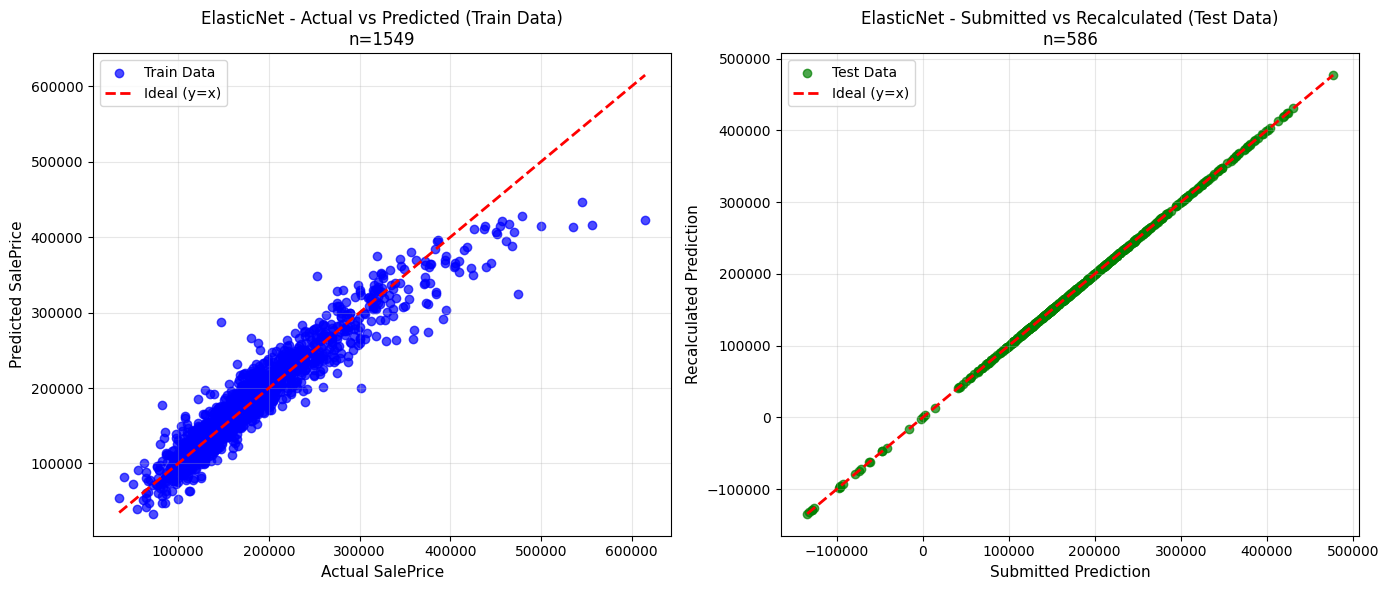


📊 예측값 통계 비교
                               Train            Test
------------------------------------------------------------
데이터 개수                         1,549             586
평균 (Mean)                 182,367.03      182,130.65
중앙값 (Median)              168,722.93      171,950.60
최소값 (Min)                  33,262.19     -134,254.83
최대값 (Max)                 446,675.06      477,204.70
표준편차 (Std)                 70,213.78       94,274.79


In [50]:
# 1. 실제값 vs 예측값 산점도 (학습 데이터 + 테스트 데이터)

# 빨간대각선은 예측=실제라는 의미로, 선에 가까울수록 예측이 정확한 모델
# 대부분의 점이 빨간선에 밀집되어있어 주택가격을 안정적으로 예측하고 있음을 확인할 수 있고,
# 예측값의 분산도 과하게 넓지 않아 오차가 일정 범위 내에서 유지됨
# 다만 고가 영역에서 일부점이 대각선에서 벗어난 걸 확인할 수 있음(고가 영역은 예측이 어려움)

# 선택된 모델로 학습 데이터 예측
y_train_actual = y_train  # 학습 데이터의 실제값
y_train_pred = selected_model.predict(selected_X_train)  # 선택된 모델로 예측

# 테스트 데이터 예측값 (이미 계산됨: y_pred)
y_test_pred = y_pred

# 서브플롯으로 학습/테스트 데이터 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 학습 데이터: 실제값 vs 예측값
axes[0].scatter(y_train_actual, y_train_pred, alpha=0.7, color='blue', label='Train Data')
axes[0].plot(
    [y_train_actual.min(), y_train_actual.max()],
    [y_train_actual.min(), y_train_actual.max()],
    'r--', linewidth=2, label="Ideal (y=x)"
)
axes[0].set_xlabel("Actual SalePrice", fontsize=11)
axes[0].set_ylabel("Predicted SalePrice", fontsize=11)
axes[0].set_title(f"{best_model_name} - Actual vs Predicted (Train Data)\nn={len(y_train_actual)}", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) 테스트 데이터: 제출 예측값 vs 재계산 예측값 산점도
# submission_test.csv에서 제출된 예측값 로드
df_sub_test_plot = pd.read_csv("submission_test.csv")
y_pred_submitted_plot = df_sub_test_plot['y_pred'].values
y_pred_recalculated_plot = y_pred  # 모델로 재계산한 예측값

axes[1].scatter(y_pred_submitted_plot, y_pred_recalculated_plot, alpha=0.7, color='green', label='Test Data')
axes[1].plot(
    [y_pred_submitted_plot.min(), y_pred_submitted_plot.max()],
    [y_pred_submitted_plot.min(), y_pred_submitted_plot.max()],
    'r--', linewidth=2, label="Ideal (y=x)"
)
axes[1].set_xlabel("Submitted Prediction", fontsize=11)
axes[1].set_ylabel("Recalculated Prediction", fontsize=11)
axes[1].set_title(f"{best_model_name} - Submitted vs Recalculated (Test Data)\nn={len(y_test_pred)}", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 예측값 비교 통계
print("\n" + "="*60)
print("📊 예측값 통계 비교")
print("="*60)
print(f"{'':20} {'Train':>15} {'Test':>15}")
print("-"*60)
print(f"{'데이터 개수':20} {len(y_train_pred):>15,} {len(y_test_pred):>15,}")
print(f"{'평균 (Mean)':20} {y_train_pred.mean():>15,.2f} {y_test_pred.mean():>15,.2f}")
print(f"{'중앙값 (Median)':20} {np.median(y_train_pred):>15,.2f} {np.median(y_test_pred):>15,.2f}")
print(f"{'최소값 (Min)':20} {y_train_pred.min():>15,.2f} {y_test_pred.min():>15,.2f}")
print(f"{'최대값 (Max)':20} {y_train_pred.max():>15,.2f} {y_test_pred.max():>15,.2f}")
print(f"{'표준편차 (Std)':20} {y_train_pred.std():>15,.2f} {y_test_pred.std():>15,.2f}")
print("="*60)

### 9.2 잔차(실제값-예측값)

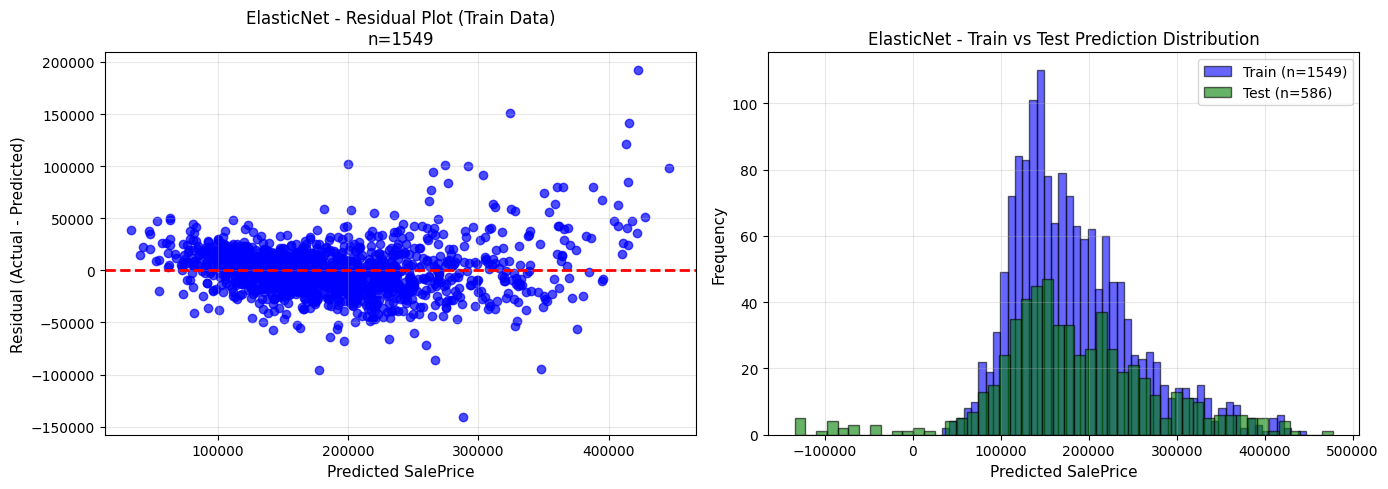


📊 학습 데이터 잔차 통계
잔차 평균: -0.00
잔차 표준편차: 23,031.52
잔차 최소: -141,104.30
잔차 최대: 192,702.59


In [51]:
# 2. 잔차(실제값-예측값) (학습 데이터) + 테스트 예측값 비교

# 그래프 결과 잔차는 0을 기준으로 상하 고르게 분포하여 특정한 예측 편향은 나타나지 않음
# 잔차가 뚜렷한 구조적 패턴 없이 랜덤하게 분포하고 있어 모델이 데이터의 선형 관계를 잘 설명
# 그래프의 오른쪽 부분에서 잔차 범위가 조금 넓어지는걸로 고가 주택에서 오차가 약간 증가하는걸 볼 수 있음
# 일부 관측치에서는 큰 잔차가 발생하여 해당 샘플이 특이값이거나 모델에서
# 설명되는 않은 요인이 존재할 가능성이 있음

residuals = y_train_actual - y_train_pred  # 실제 - 예측

# 서브플롯으로 학습/테스트 데이터 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 학습 데이터: 잔차 플롯
axes[0].scatter(y_train_pred, residuals, alpha=0.7, color='blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel("Predicted SalePrice", fontsize=11)
axes[0].set_ylabel("Residual (Actual - Predicted)", fontsize=11)
axes[0].set_title(f"{best_model_name} - Residual Plot (Train Data)\nn={len(residuals)}", fontsize=12)
axes[0].grid(True, alpha=0.3)

# (2) 학습 vs 테스트: 예측값 분포 비교
axes[1].hist(y_train_pred, bins=50, alpha=0.6, color='blue', label=f'Train (n={len(y_train_pred)})', edgecolor='black')
axes[1].hist(y_test_pred, bins=50, alpha=0.6, color='green', label=f'Test (n={len(y_test_pred)})', edgecolor='black')
axes[1].set_xlabel("Predicted SalePrice", fontsize=11)
axes[1].set_ylabel("Frequency", fontsize=11)
axes[1].set_title(f"{best_model_name} - Train vs Test Prediction Distribution", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 잔차 통계
print("\n" + "="*60)
print("📊 학습 데이터 잔차 통계")
print("="*60)
print(f"잔차 평균: {residuals.mean():,.2f}")
print(f"잔차 표준편차: {residuals.std():,.2f}")
print(f"잔차 최소: {residuals.min():,.2f}")
print(f"잔차 최대: {residuals.max():,.2f}")
print("="*60)

# 10. 기타 및 부록

### 10.1 기타
- submission_train.csv 생성

In [52]:
# =============================================================================
# 📌 submission_train.csv 생성 (원본 Train 데이터 전체 2344개)
# =============================================================================
# 이상치 제거 없이 원본 데이터 전체에 대해 전처리 후 예측

# 1. 원본 데이터 다시 로드
df_train_full = pd.read_csv("regression_train_public.csv")
df_train_full.columns = df_train_full.columns.str.strip()
df_train_full = df_train_full.rename(columns=reg_map)

# 범주형 변수 값을 소문자로 통일
for col in df_train_full.select_dtypes(include='object').columns:
    df_train_full[col] = df_train_full[col].str.lower()

# 필요한 컬럼만 선택
df_train_full = df_train_full[list(reg_map.values())]

# y_true 저장 (원본 정답)
y_true_full = df_train_full['sale_price'].copy()

print(f"원본 Train 데이터: {len(df_train_full)}개")

# =============================================================================
# 2. 결측치 처리 (학습 데이터와 동일한 방식, 행 삭제 없이!)
# =============================================================================

# Garage 관련 결측치 처리
mask_garage_both_null = df_train_full['garage_finish'].isnull() & df_train_full['garage_type'].isnull()
df_train_full.loc[mask_garage_both_null, 'garage_finish'] = 'nogarage'
df_train_full.loc[mask_garage_both_null, 'garage_type'] = 'nogarage'

# garage_finish만 결측인 경우 (garage_type은 있는 경우) - detchd 그룹의 최빈값 사용
mask_finish_null = df_train_full['garage_finish'].isnull()
if mask_finish_null.sum() > 0:
    df_train_full.loc[mask_finish_null, 'garage_finish'] = 'unf'

# garage_cars 결측치 처리
mask_cars_null = df_train_full['garage_cars'].isnull() & (df_train_full['garage_type'] == 'detchd')
df_train_full.loc[mask_cars_null, 'garage_cars'] = 1.0  # detchd+unf 그룹 최빈값
df_train_full['garage_cars'] = df_train_full['garage_cars'].fillna(0)

# Bsmt 관련 결측치 처리 (행 삭제 대신 0으로 채움!)
df_train_full['total_bsmt_sf'] = df_train_full['total_bsmt_sf'].fillna(0)
no_bsmt_mask = df_train_full['total_bsmt_sf'] == 0

for col in ['bsmt_qual', 'bsmt_exposure', 'bsmt_fin_type1']:
    if col in df_train_full.columns:
        df_train_full.loc[no_bsmt_mask, col] = df_train_full.loc[no_bsmt_mask, col].fillna('nobsmt')

# 남은 bsmt_exposure 결측치 (지하실 있지만 exposure만 결측) - 조합별 최빈값
bsmt_exposure_null = df_train_full['bsmt_exposure'].isnull()
if bsmt_exposure_null.sum() > 0:
    # df_clean에서 계산한 조합별 최빈값 사용
    for idx in df_train_full[bsmt_exposure_null].index:
        qual = df_train_full.loc[idx, 'bsmt_qual']
        fin_type = df_train_full.loc[idx, 'bsmt_fin_type1']
        # 기본값으로 'no' 사용 (가장 일반적)
        df_train_full.loc[idx, 'bsmt_exposure'] = 'no'

# fireplace_qu 결측치 처리
mask_no_fireplace = (df_train_full['fireplaces'] == 0)
df_train_full.loc[mask_no_fireplace & df_train_full['fireplace_qu'].isnull(), 'fireplace_qu'] = 'nofireplace'

# =============================================================================
# 3. lot_frontage 결측치 - 학습된 회귀 모델로 대치
# =============================================================================
mask_lot_nan_full = df_train_full['lot_frontage'].isnull()
print(f"lot_frontage 결측치 개수: {mask_lot_nan_full.sum()}")

if mask_lot_nan_full.sum() > 0:
    # 저장된 lot_frontage 모델 불러오기
    lot_model_data = joblib.load("model_lot_frontage.pkl")
    lot_model = lot_model_data['model']
    lot_features = lot_model_data['features']
    lot_cat_features = lot_model_data['cat_features']
    
    # 더미화 수행
    df_train_reg = df_train_full.copy()
    df_train_reg = pd.get_dummies(df_train_reg, columns=lot_cat_features, drop_first=True)
    
    # 학습 데이터의 피처와 맞추기
    for col in lot_features:
        if col not in df_train_reg.columns:
            df_train_reg[col] = 0
    
    # 결측치 행만 예측
    X_lot_pred_full = df_train_reg.loc[mask_lot_nan_full, lot_features]
    lot_pred_full = lot_model.predict(X_lot_pred_full)
    
    # 결측치에 예측값 대입
    df_train_full.loc[mask_lot_nan_full, 'lot_frontage'] = lot_pred_full
    print(f"lot_frontage 결측치 대치 완료!")

# =============================================================================
# 4. 로그 변환 (학습 데이터와 동일)
# =============================================================================
log_cols_full = ['lot_area', 'gr_liv_area', 'total_bsmt_sf', 'open_porch_sf', 'lot_frontage']

for col in log_cols_full:
    if col in df_train_full.columns:
        df_train_full[col] = np.log1p(df_train_full[col])

print("로그 변환 완료!")

# =============================================================================
# 5. 타깃 인코딩 (학습 데이터에서 계산한 매핑값 사용)
# =============================================================================
target_encoding_cols = ['kitchen_qual', 'exter_qual', 'bsmt_qual', 'fireplace_qu', 'paved_drive']

# 학습 데이터(df_clean)에서 각 범주별 sale_price 평균 계산
te_mapping_full = {}
for col in target_encoding_cols:
    if col in df_clean.columns:
        te_mapping_full[col] = df_clean.groupby(col)['sale_price'].mean().to_dict()

# 전체 Train 데이터에 타깃 인코딩 적용
df_train_encoded = df_train_full.copy()
global_mean_full = df_clean['sale_price'].mean()

for col in target_encoding_cols:
    if col in df_train_encoded.columns and col in te_mapping_full:
        df_train_encoded[f'{col}_te'] = df_train_encoded[col].map(te_mapping_full[col]).fillna(global_mean_full)
        df_train_encoded = df_train_encoded.drop(columns=[col])

print("타깃 인코딩 완료!")

# =============================================================================
# 6. 원핫 인코딩
# =============================================================================
# sale_price 컬럼 제거 (타깃 변수)
if 'sale_price' in df_train_encoded.columns:
    df_train_encoded = df_train_encoded.drop(columns=['sale_price'])

remaining_cat_cols_full = df_train_encoded.select_dtypes(include='object').columns.tolist()
df_train_encoded = pd.get_dummies(df_train_encoded, columns=remaining_cat_cols_full, drop_first=True)

print("원핫 인코딩 완료!")

# =============================================================================
# 7. 스케일링 (학습 때 fit한 scaler 사용!)
# =============================================================================
train_cols_full = X_scaled.columns.tolist()

# 컬럼 맞추기
for col in train_cols_full:
    if col not in df_train_encoded.columns:
        df_train_encoded[col] = 0

# 컬럼 순서 맞추기
df_train_encoded = df_train_encoded.reindex(columns=train_cols_full, fill_value=0)

# 스케일링 적용 (학습 때 fit한 scaler 사용!)
X_train_full_scaled = scaler.transform(df_train_encoded)
X_train_full_scaled = pd.DataFrame(X_train_full_scaled, columns=train_cols_full)

print(f"스케일링 완료! Shape: {X_train_full_scaled.shape}")

# =============================================================================
# 8. 모델로 예측
# =============================================================================
model = joblib.load('model.pkl')

# 모델이 사용하는 피처만 선택
model_features = list(model.feature_names_in_)
X_for_submission = X_train_full_scaled.reindex(columns=model_features, fill_value=0)

# 예측
y_pred_full = model.predict(X_for_submission)

print(f"예측 완료! 예측값 개수: {len(y_pred_full)}")

# =============================================================================
# 9. submission_train.csv 저장
# =============================================================================
df_sub_train = X_for_submission.copy()
df_sub_train['y_true'] = y_true_full.values
df_sub_train['y_pred'] = y_pred_full

df_sub_train.to_csv("submission_train.csv", index=False)

print("\n" + "="*60)
print("📁 submission_train.csv 저장 완료!")
print("="*60)
print(f"Shape: {df_sub_train.shape}")
print(f"행 개수: {len(df_sub_train)} (원본과 동일해야 함: 2344)")

원본 Train 데이터: 2344개
lot_frontage 결측치 개수: 393
lot_frontage 결측치 대치 완료!
로그 변환 완료!
타깃 인코딩 완료!
원핫 인코딩 완료!
스케일링 완료! Shape: (2344, 77)
예측 완료! 예측값 개수: 2344

📁 submission_train.csv 저장 완료!
Shape: (2344, 79)
행 개수: 2344 (원본과 동일해야 함: 2344)


In [53]:
# ============================================================
# Train Set 정밀도 문제 해결
# ============================================================
print("Train Set 정밀도 검증:")
print("-" * 40)

# submission_train.csv에서 제출된 예측값 로드
df_sub_train_loaded = pd.read_csv("submission_train.csv")
y_pred_train_submitted = df_sub_train_loaded['y_pred'].values

# 모델로 재계산한 예측값
y_pred_train_recalculated = y_pred_full

# 방법 1: np.isclose 사용 (추천)
# rtol(상대오차), atol(절대오차)을 설정하여 미세한 차이를 허용합니다.
is_close_match_train = np.isclose(y_pred_train_submitted, y_pred_train_recalculated, rtol=1e-5).all()
print(f"np.isclose() 비교 결과: {is_close_match_train}")

# 방법 2: 반올림(round) 후 비교
# 소수점 5자리까지 반올림
y_pred_train_submitted_rounded = y_pred_train_submitted.round(5)
y_pred_train_recalculated_rounded = y_pred_train_recalculated.round(5)

is_rounded_match_train = (y_pred_train_submitted_rounded == y_pred_train_recalculated_rounded).all()
print(f"반올림(round) 후 비교 결과: {is_rounded_match_train}")

# ============================================================
# Test Set 정밀도 문제 해결
# ============================================================
print("\nTest Set 정밀도 검증:")
print("-" * 40)

# submission_test.csv에서 제출된 예측값 로드
df_sub_test_loaded = pd.read_csv("submission_test.csv")
y_pred_submitted = df_sub_test_loaded['y_pred'].values

# 모델로 재계산한 예측값
y_pred_recalculated = y_pred

# 방법 1: np.isclose 사용 (추천)
is_close_match = np.isclose(y_pred_submitted, y_pred_recalculated, rtol=1e-5).all()
print(f"np.isclose() 비교 결과: {is_close_match}")

# 방법 2: 반올림(round) 후 비교
y_pred_submitted_rounded = y_pred_submitted.round(5)
y_pred_recalculated_rounded = y_pred_recalculated.round(5)

is_rounded_match = (y_pred_submitted_rounded == y_pred_recalculated_rounded).all()
print(f"반올림(round) 후 비교 결과: {is_rounded_match}")

Train Set 정밀도 검증:
----------------------------------------
np.isclose() 비교 결과: True
반올림(round) 후 비교 결과: True

Test Set 정밀도 검증:
----------------------------------------
np.isclose() 비교 결과: True
반올림(round) 후 비교 결과: True


### 10.2 부록

##### 10.2.1 Lot Frontage 변수 중앙값 대치

In [54]:
# # Lot Frontage 결측치 처리: 'Neighborhood'별 중앙값으로 대치
# # 'Lot Frontage'가 결측치인 경우, 해당 'Neighborhood'의 중앙값으로 채웁니다.
# df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# # 처리 후 결측치 개수 확인
# print("Lot Frontage 결측치 처리 후:", df['Lot Frontage'].isnull().sum())

##### 10.2.2 라벨 인코딩

In [55]:
# # 라벨 인코딩

# from sklearn.preprocessing import LabelEncoder

# df_encoded = df_clean.copy()

# for col in le_cols:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# # One-Hot-Encoding
# df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# print(f'인코딩 후 컬럼 개수 : {len(df_encoded.columns)}')
